# Data cleaning and processing

In [1]:
import pandas as pd
import numpy as np
df_co2=pd.read_csv('./data/co2-emissions-per-capita.csv')
print('数据加载成功，请查看：')
print(df_co2.head())
print('\n')
print(df_co2.info())

df_co2 = df_co2.rename(columns={
    'Entity': 'Countries',
    'Annual CO₂ emissions (per capita)': 'CO2_Per_Capita'
})
print('改名成功，加载部分数据： ')
print(df_co2.head())
selected_countries=[
    'United States', 
    'Canada', 
    'China', 
    'Japan',
    'Germany',     
    'United Kingdom', 
    'France',      
    'Italy',       
    'Russia',
    'Spain',
    'Portugal',
    'Netherlands',
    'Denmark',
    'Finland',
    'Austria',
    'Norway',
    'Switzerland',
    'Sweden',
    'Indonesia',
    'India',
    'South Africa',
    'Nigeria',
    'Brazil',
    'Mexico'
]
df_final_co2=df_co2[
    (df_co2['Year']>=1990)&
    (df_co2['Year']<=2022)&
    (df_co2['Countries'].isin(selected_countries))
]
print(f'\n最终数据大小:{len(df_final_co2)}')
print(df_final_co2.head())

df_final_co2.to_csv('./data/co2_final_clean.csv',index=False)
print('数据保存完成')
df_energy=pd.read_csv('./data/energy-use-per-person.csv')
print('数据加载完成： ')
print('\n')
print(df_energy.head())
print(df_energy.info())
df_energy=df_energy.rename(columns={
    'Entity':'Countries',
    'Primary energy consumption per capita (kWh/person)': 'Energy_Per_Capita'
})
print('改名完成： ')
print(df_energy.head())
df_final_energy=df_energy[
    (df_energy['Year']>=1990)&
    (df_energy['Year']<=2022)&
    (df_energy['Countries'].isin(selected_countries))
]
print(f'数据整理完成：{len(df_final_energy)}')
print(df_final_energy.head())
df_final_energy.to_csv('./data/energy_final_clean.csv',index=False)
print('数据保存完成')
df_data=pd.read_csv('./data/owid-energy-data.csv')
print(df_data.head())
print(df_data.info())
df_data=df_data.rename(columns={
    'year':'Year',
    'country':'Countries'
})
print(df_data.head())
df_final_data = df_data[
    (df_data['Year'] >= 1990) &
    (df_data['Year'] <= 2022) &
    (df_data['Countries'].isin(selected_countries)) &
    df_data['population'].notna() &
    df_data['gdp'].notna()
][['Countries', 'Year', 'gdp', 'population']]
print(df_final_data.head())
df_final_data.to_csv('./data/gdp_pop_final.csv',index=False)
df_final_co2=pd.read_csv('./data/co2_final_clean.csv')
df_final_energy=pd.read_csv('./data/energy_final_clean.csv')
df_final_gdp=pd.read_csv('./data/gdp_pop_final.csv')
print('数据加载完成： ')
print(df_final_co2.head())
print(df_final_energy.head())
print(df_final_gdp.head())
df_merge = pd.merge(
    df_final_co2,
    df_final_energy,
    on=['Countries', 'Year'],
    how='inner'
)
df_merge = pd.merge(
    df_merge,
    df_final_gdp,
    on=['Countries', 'Year'],
    how='inner'
)
print(f'合并完成，数据长度：{len(df_merge)}')
print('数据预览： ')
print('\n')
print(df_merge.head())
df_merge.to_csv('./data/merge_data_clean.csv',index=False)

developing_countries = ['Brazil', 
                        'China', 
                        'India', 
                        'Indonesia', 
                        'Mexico', 
                        'Nigeria', 
                        'Russia', 
                        'South Africa']
developed_countries = ['Austria', 
                       'Canada', 
                       'Denmark', 
                       'Finland', 
                       'France', 
                       'Germany', 
                       'Italy', 
                       'Japan', 
                       'Netherland', 
                       'Norway', 
                       'Portugal', 
                       'Spain', 
                       'Sweden', 
                       'Switzerland', 
                       'United Kindom', 
                       'United States']

df_merge_developing = df_merge[(df_merge['Countries'].isin(developing_countries))]
df_merge_developed = df_merge[(df_merge['Countries'].isin(developed_countries))]

df_merge_developing.to_csv('./data/merge_data_developing.csv', index = False)
df_merge_developed.to_csv('./data/merge_data_developed.csv', index = False)

数据加载成功，请查看：
        Entity  Year  Annual CO₂ emissions (per capita)
0  Afghanistan  1949                           0.001992
1  Afghanistan  1950                           0.010837
2  Afghanistan  1951                           0.011625
3  Afghanistan  1952                           0.011468
4  Afghanistan  1953                           0.013123


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26278 entries, 0 to 26277
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Entity                             26278 non-null  object 
 1   Year                               26278 non-null  int64  
 2   Annual CO₂ emissions (per capita)  26278 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 616.0+ KB
None
改名成功，加载部分数据： 
     Countries  Year  CO2_Per_Capita
0  Afghanistan  1949        0.001992
1  Afghanistan  1950        0.010837
2  Afghanistan  1951        

## Consistency check

In [2]:
consistency_check=df_merge.groupby('Countries')['Year'].count().reset_index()
expect_year=33
print(consistency_check)
no_consistency=consistency_check[
    (consistency_check['Year']!=33)
]
print(no_consistency)

         Countries  Year
0          Austria    33
1           Brazil    33
2           Canada    33
3            China    33
4          Denmark    33
5          Finland    33
6           France    33
7          Germany    33
8            India    33
9        Indonesia    33
10           Italy    33
11           Japan    33
12          Mexico    33
13     Netherlands    33
14         Nigeria    33
15          Norway    33
16        Portugal    33
17          Russia    33
18    South Africa    33
19           Spain    33
20          Sweden    33
21     Switzerland    33
22  United Kingdom    33
23   United States    33
Empty DataFrame
Columns: [Countries, Year]
Index: []


# Descriptive Analysis & Visualization

## Global Trends

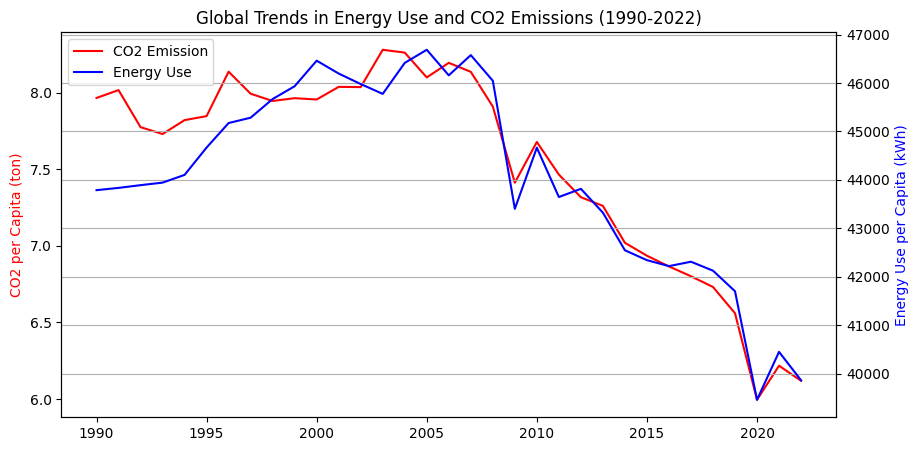

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/merge_data_clean.csv')
df_trend_global = df[(df['Year'] >= 1990) & (df['Year'] <= 2022)]
global_trend = df_trend_global.groupby('Year')[['CO2_Per_Capita', 'Energy_Per_Capita']].mean().reset_index()

plt.figure(figsize=(10,5))
line1, = plt.plot(global_trend['Year'], global_trend['CO2_Per_Capita'], 
                  label='CO2 Emission', color='red')
plt.ylabel('CO2 per Capita (ton)', color='red')
ax2 = plt.twinx()
line2, = ax2.plot(global_trend['Year'], global_trend['Energy_Per_Capita'], 
                  label='Energy Use', color='blue')
ax2.set_ylabel('Energy Use per Capita (kWh)', color='blue')
plt.title('Global Trends in Energy Use and CO2 Emissions (1990-2022)')
plt.xlabel('Year')
plt.legend(handles=[line1, line2], loc='upper left')
plt.grid(True)
plt.show()

## Top 10 countries in growth

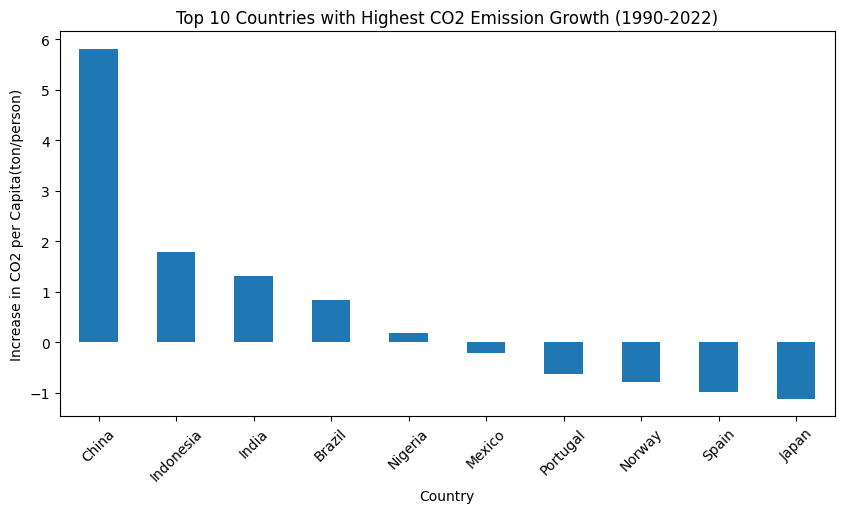

In [3]:
growth = df_trend_global.groupby('Countries')['CO2_Per_Capita'].apply(lambda x: x.iloc[-1] - x.iloc[0])
top10 = growth.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 Countries with Highest CO2 Emission Growth (1990-2022)')
plt.ylabel('Increase in CO2 per Capita(ton/person)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

## Correlation Matrix

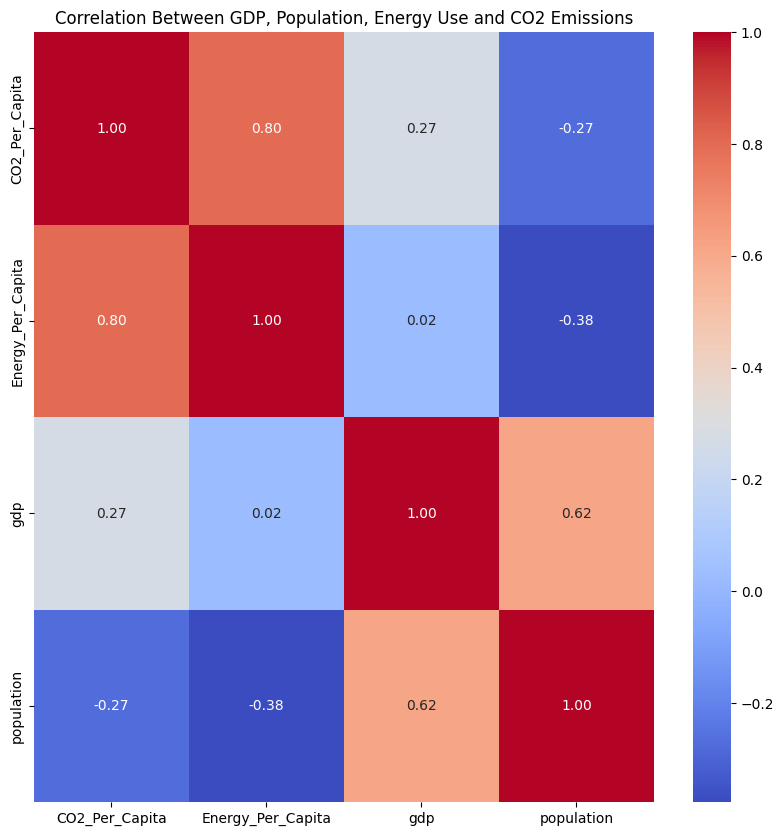

In [4]:

corr_data = df[['CO2_Per_Capita','Energy_Per_Capita','gdp','population']]
corr = corr_data.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between GDP, Population, Energy Use and CO2 Emissions')
plt.show()

## Comparative bar charts

### 1990 & 2022

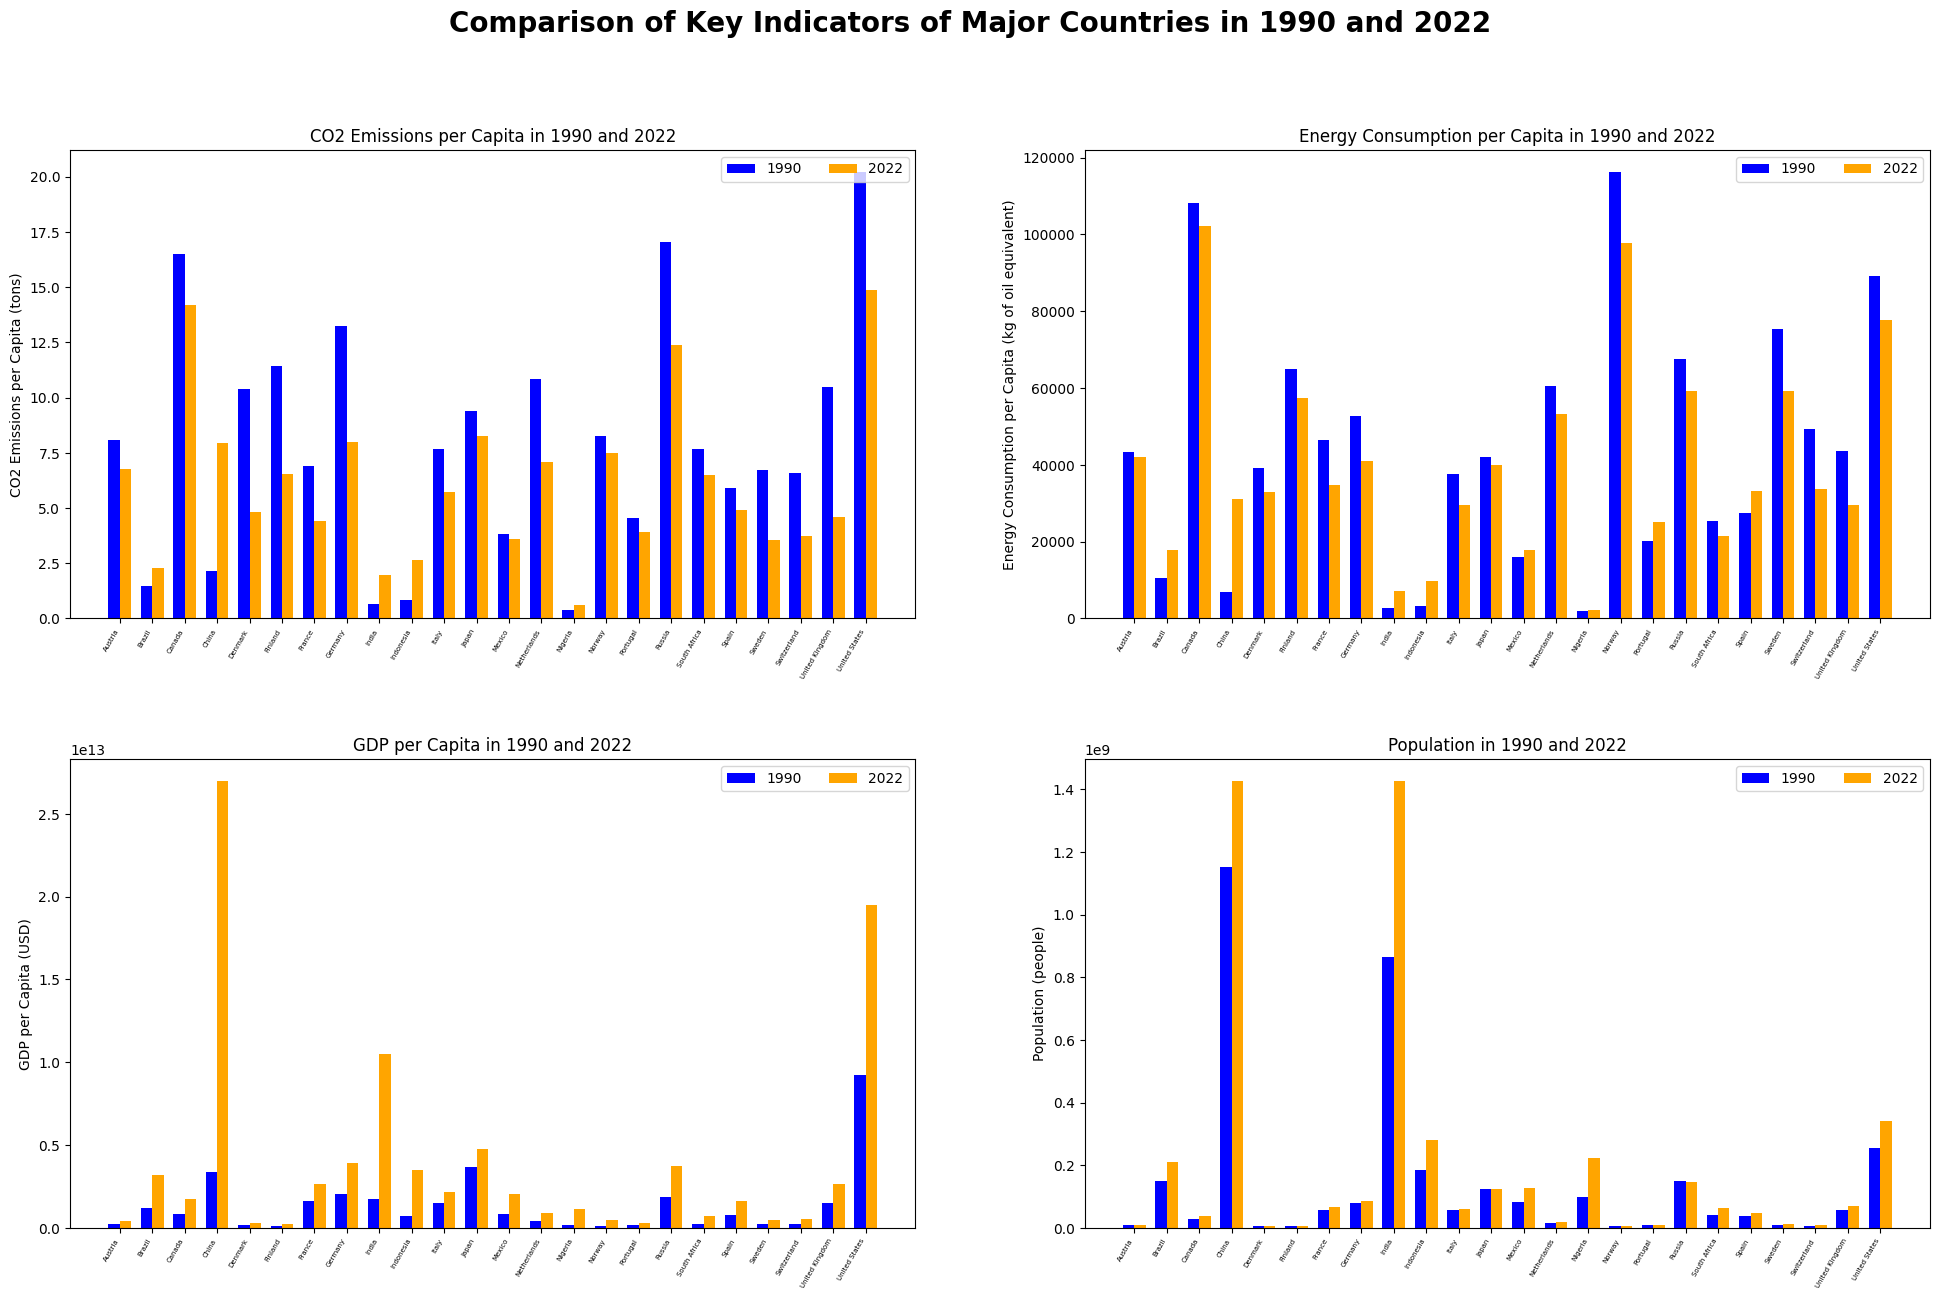

In [5]:
df = pd.read_csv('./data/merge_data_clean.csv')
fig, axes = plt.subplots(2, 2, figsize=(24, 14))
fig.suptitle('Comparison of Key Indicators of Major Countries in 1990 and 2022', fontsize=20, fontweight='bold', y=0.98)
width = 0.35
plt.subplots_adjust(hspace=0.3)
countries = df['Countries'].unique()
year_1990 = df[df['Year'] == 1990]
year_2022 = df[df['Year'] == 2022]
x = np.arange(len(countries))


ax1 = axes[0, 0]
bar_1 = ax1.bar(x-width/2,year_1990['CO2_Per_Capita'],width,label='1990',color='blue')
bar_2 = ax1.bar(x+width/2,year_2022['CO2_Per_Capita'],width,label='2022',color='orange')
ax1.set_ylabel('CO2 Emissions per Capita (tons)') 
ax1.set_title('CO2 Emissions per Capita in 1990 and 2022')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, fontsize=5,rotation=60, ha='right')
ax1.legend(loc='upper right', ncols=3)

ax2 = axes[0, 1]
bar_1 = ax2.bar(x-width/2,year_1990['Energy_Per_Capita'],width,label='1990',color='blue')
bar_2 = ax2.bar(x+width/2,year_2022['Energy_Per_Capita'],width,label='2022',color='orange')
ax2.set_ylabel('Energy Consumption per Capita (kg of oil equivalent)')
ax2.set_title('Energy Consumption per Capita in 1990 and 2022')
ax2.set_xticks(x)
ax2.set_xticklabels(countries, fontsize=5,rotation=60, ha='right')
ax2.legend(loc='upper right', ncols=3)

ax3 = axes[1, 0]
bar_1 = ax3.bar(x-width/2,year_1990['gdp'],width,label='1990',color='blue')
bar_2 = ax3.bar(x+width/2,year_2022['gdp'],width,label='2022',color='orange')
ax3.set_ylabel('GDP per Capita (USD)')
ax3.set_title('GDP per Capita in 1990 and 2022')
ax3.set_xticks(x)
ax3.set_xticklabels(countries, fontsize=5,rotation=60, ha='right')
ax3.legend(loc='upper right', ncols=3)

ax4 = axes[1, 1]
bar_1 = ax4.bar(x-width/2,year_1990['population'],width,label='1990',color='blue')
bar_2 = ax4.bar(x+width/2,year_2022['population'],width,label='2022',color='orange')
ax4.set_ylabel('Population (people)')
ax4.set_title('Population in 1990 and 2022')
ax4.set_xticks(x)
ax4.set_xticklabels(countries, fontsize=5,rotation=60, ha='right')
ax4.legend(loc='upper right', ncols=3)

### Average data from 1990-2022

C:\Users\yanxu\AppData\Local\Temp\ipykernel_9400\1218521324.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


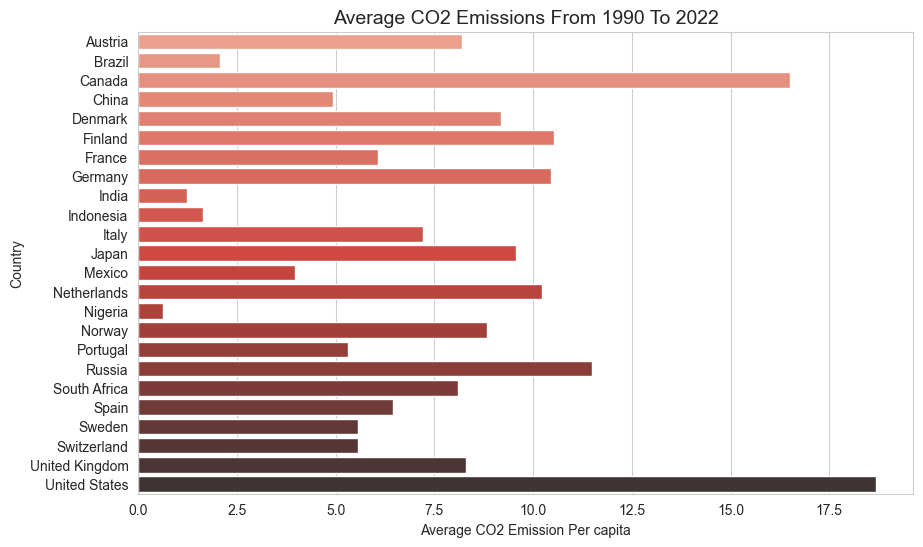

C:\Users\yanxu\AppData\Local\Temp\ipykernel_9400\1218521324.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


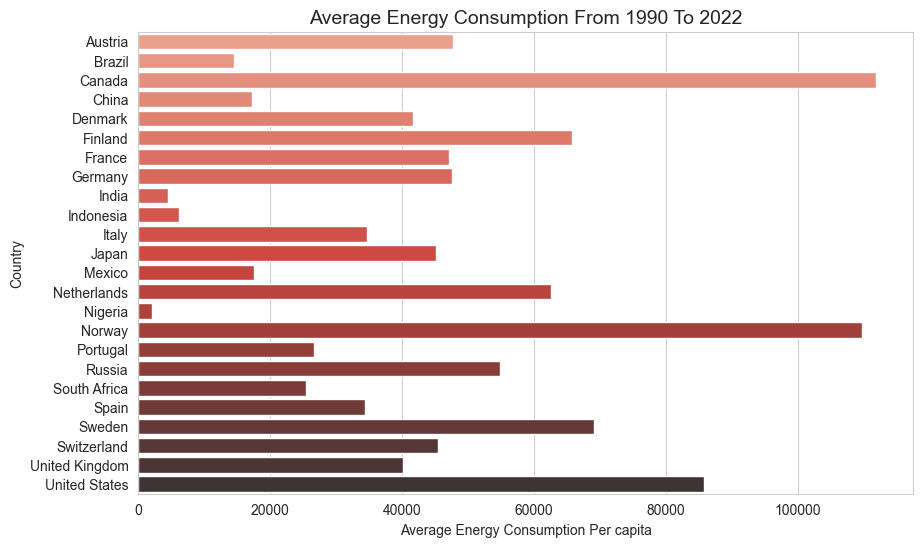

In [6]:
df_data=pd.read_csv('./data/merge_data_clean.csv') 
group_data=df_data.groupby('Countries').agg(
    Average_CO2=('CO2_Per_Capita','mean'),
    Average_Energy=('Energy_Per_Capita','mean')
).reset_index()
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.barplot(
    x='Average_CO2',
    y='Countries',
    data=group_data,
    palette="Reds_d"
)
plt.title('Average CO2 Emissions From 1990 To 2022',fontsize=14)
plt.xlabel('Average CO2 Emission Per capita')
plt.ylabel('Country')
plt.show()
plt.figure(figsize=(10,6))
sns.barplot(
    x='Average_Energy',
    y='Countries',
    data=group_data,
    palette="Reds_d"
)
plt.title('Average Energy Consumption From 1990 To 2022',fontsize=14)
plt.xlabel('Average Energy Consumption Per capita')
plt.ylabel('Country')
plt.show()

## Time-series plots 

### Time-series of representative countries

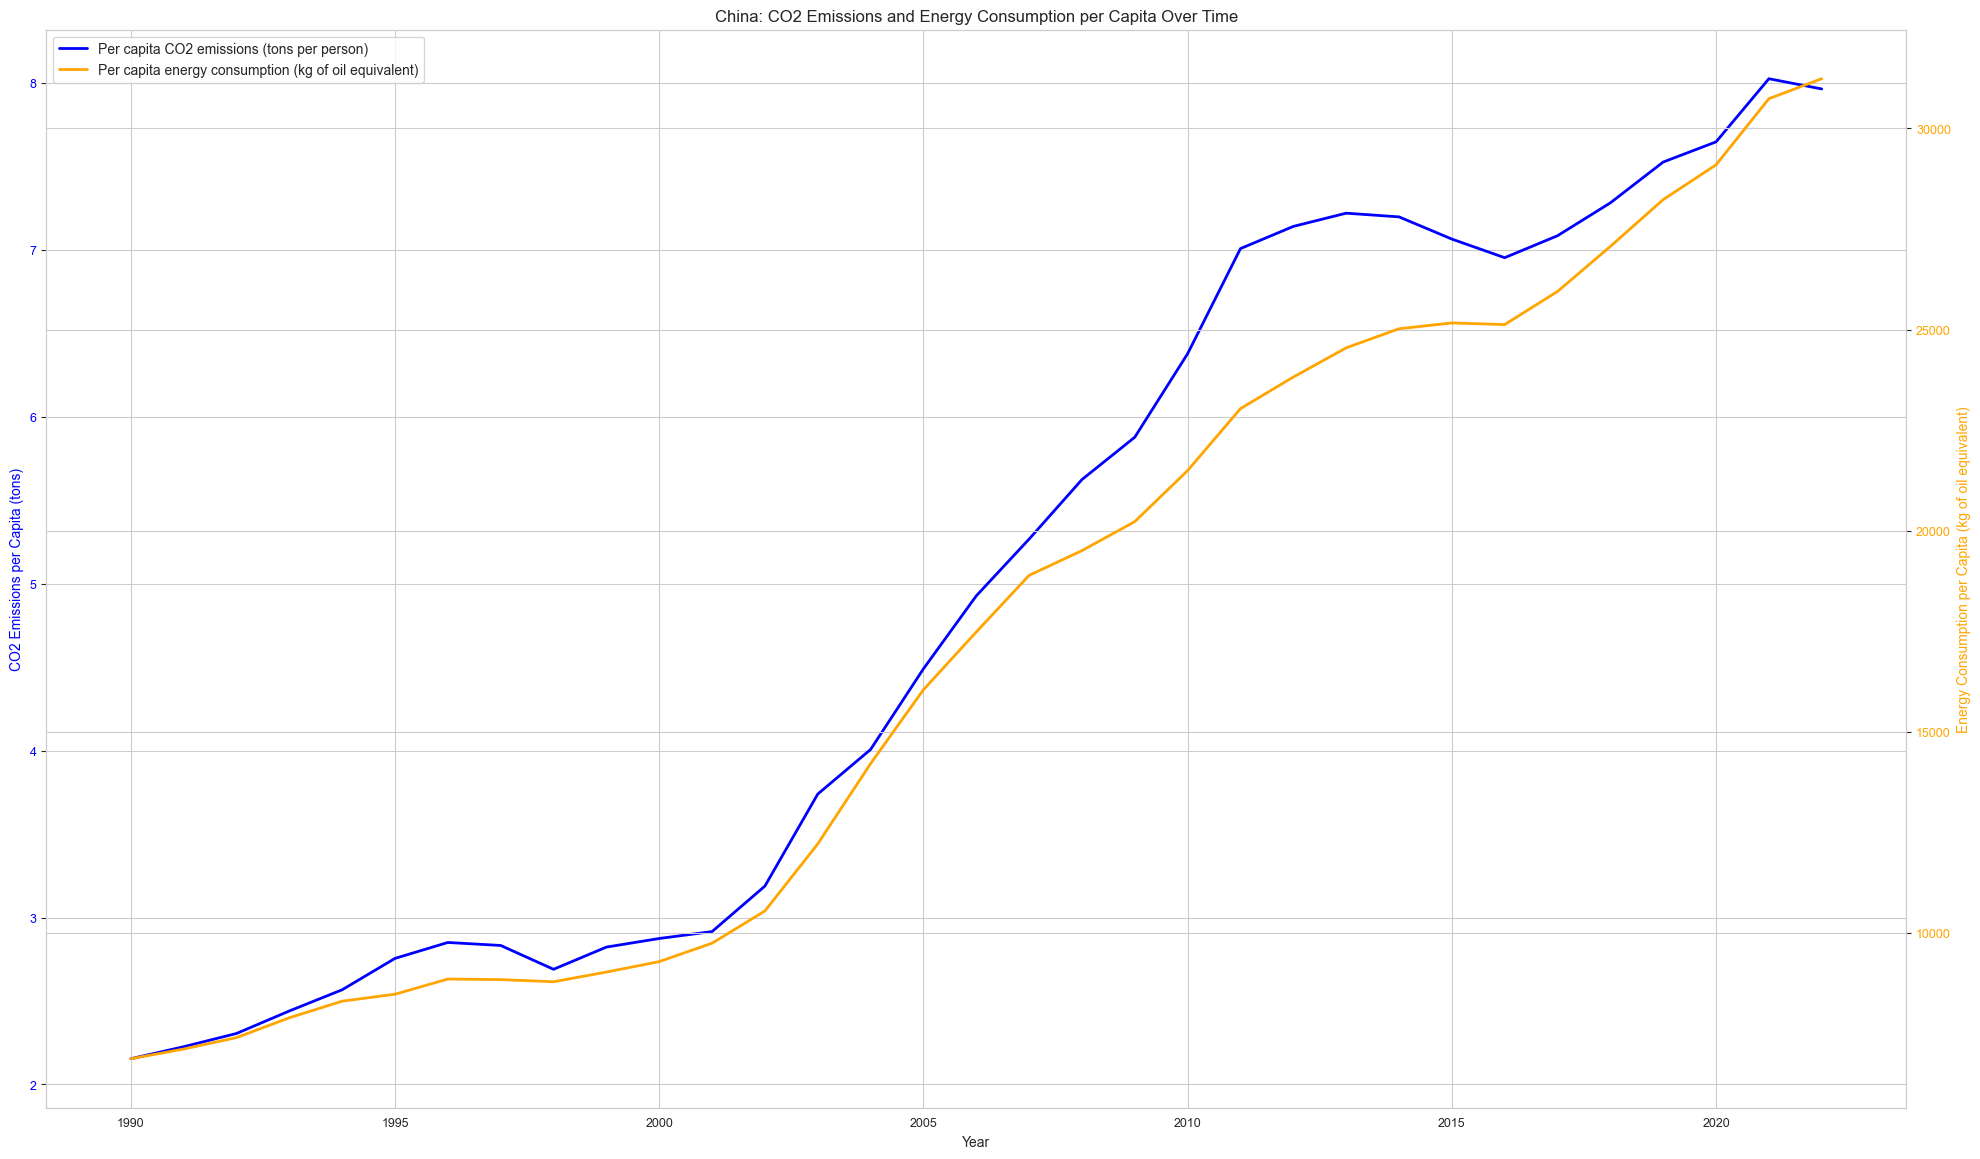

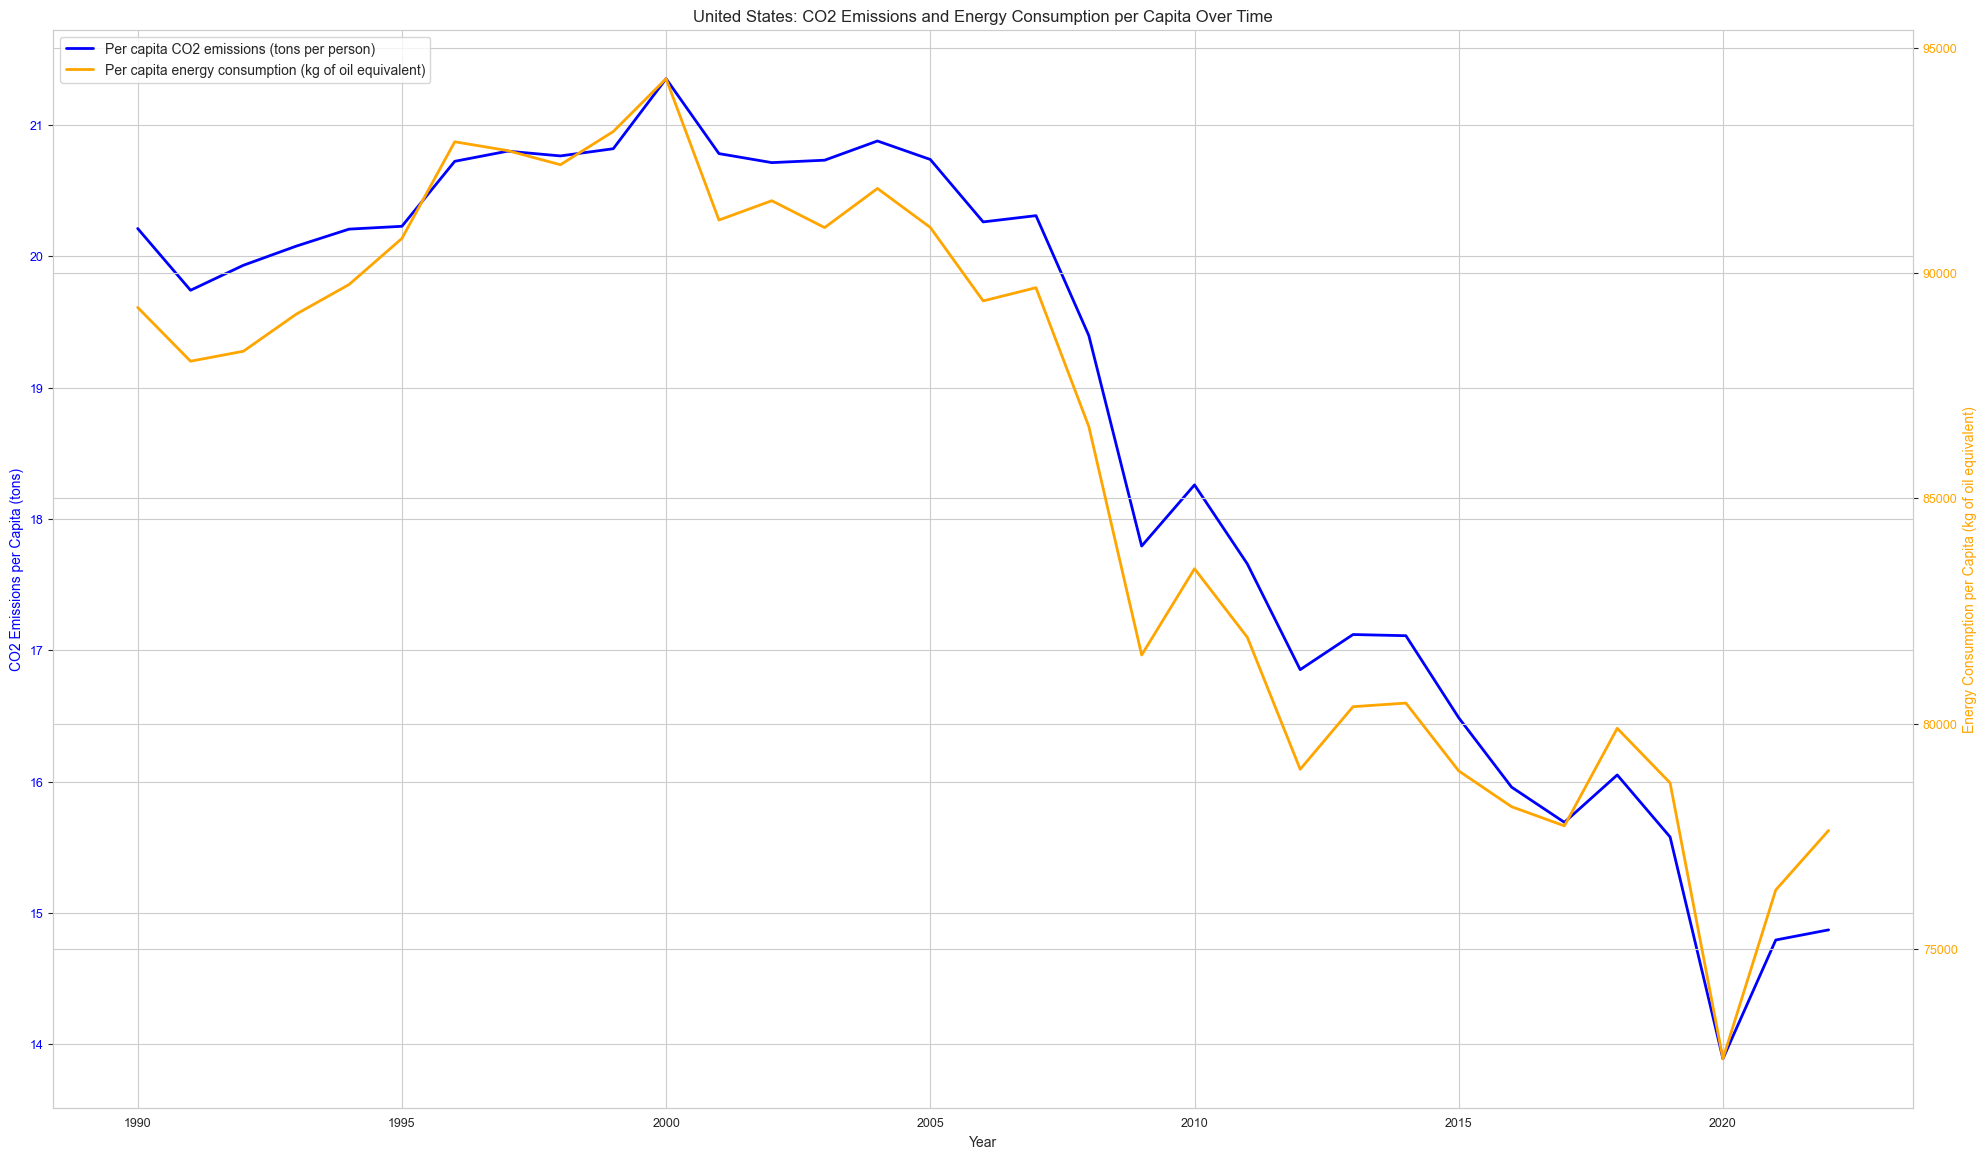

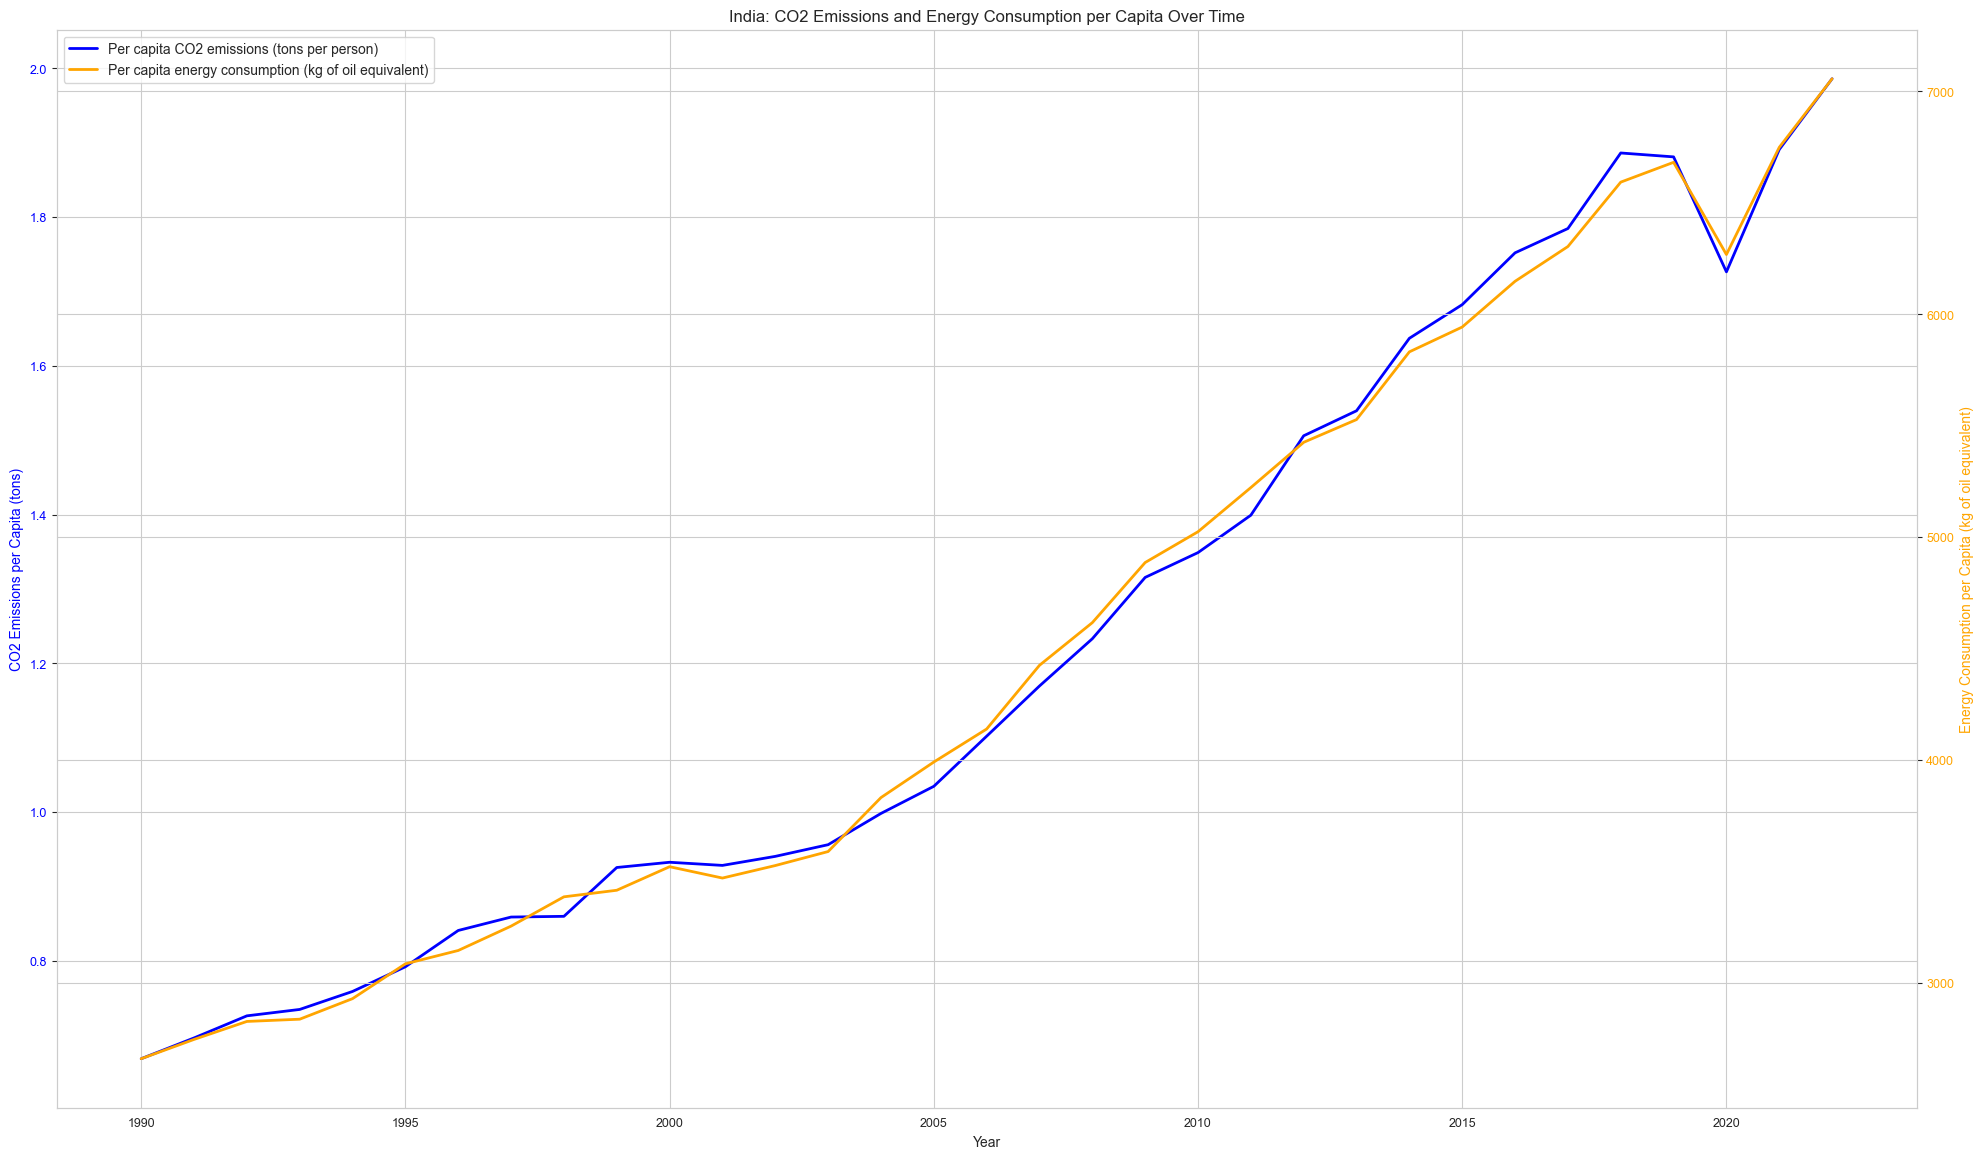

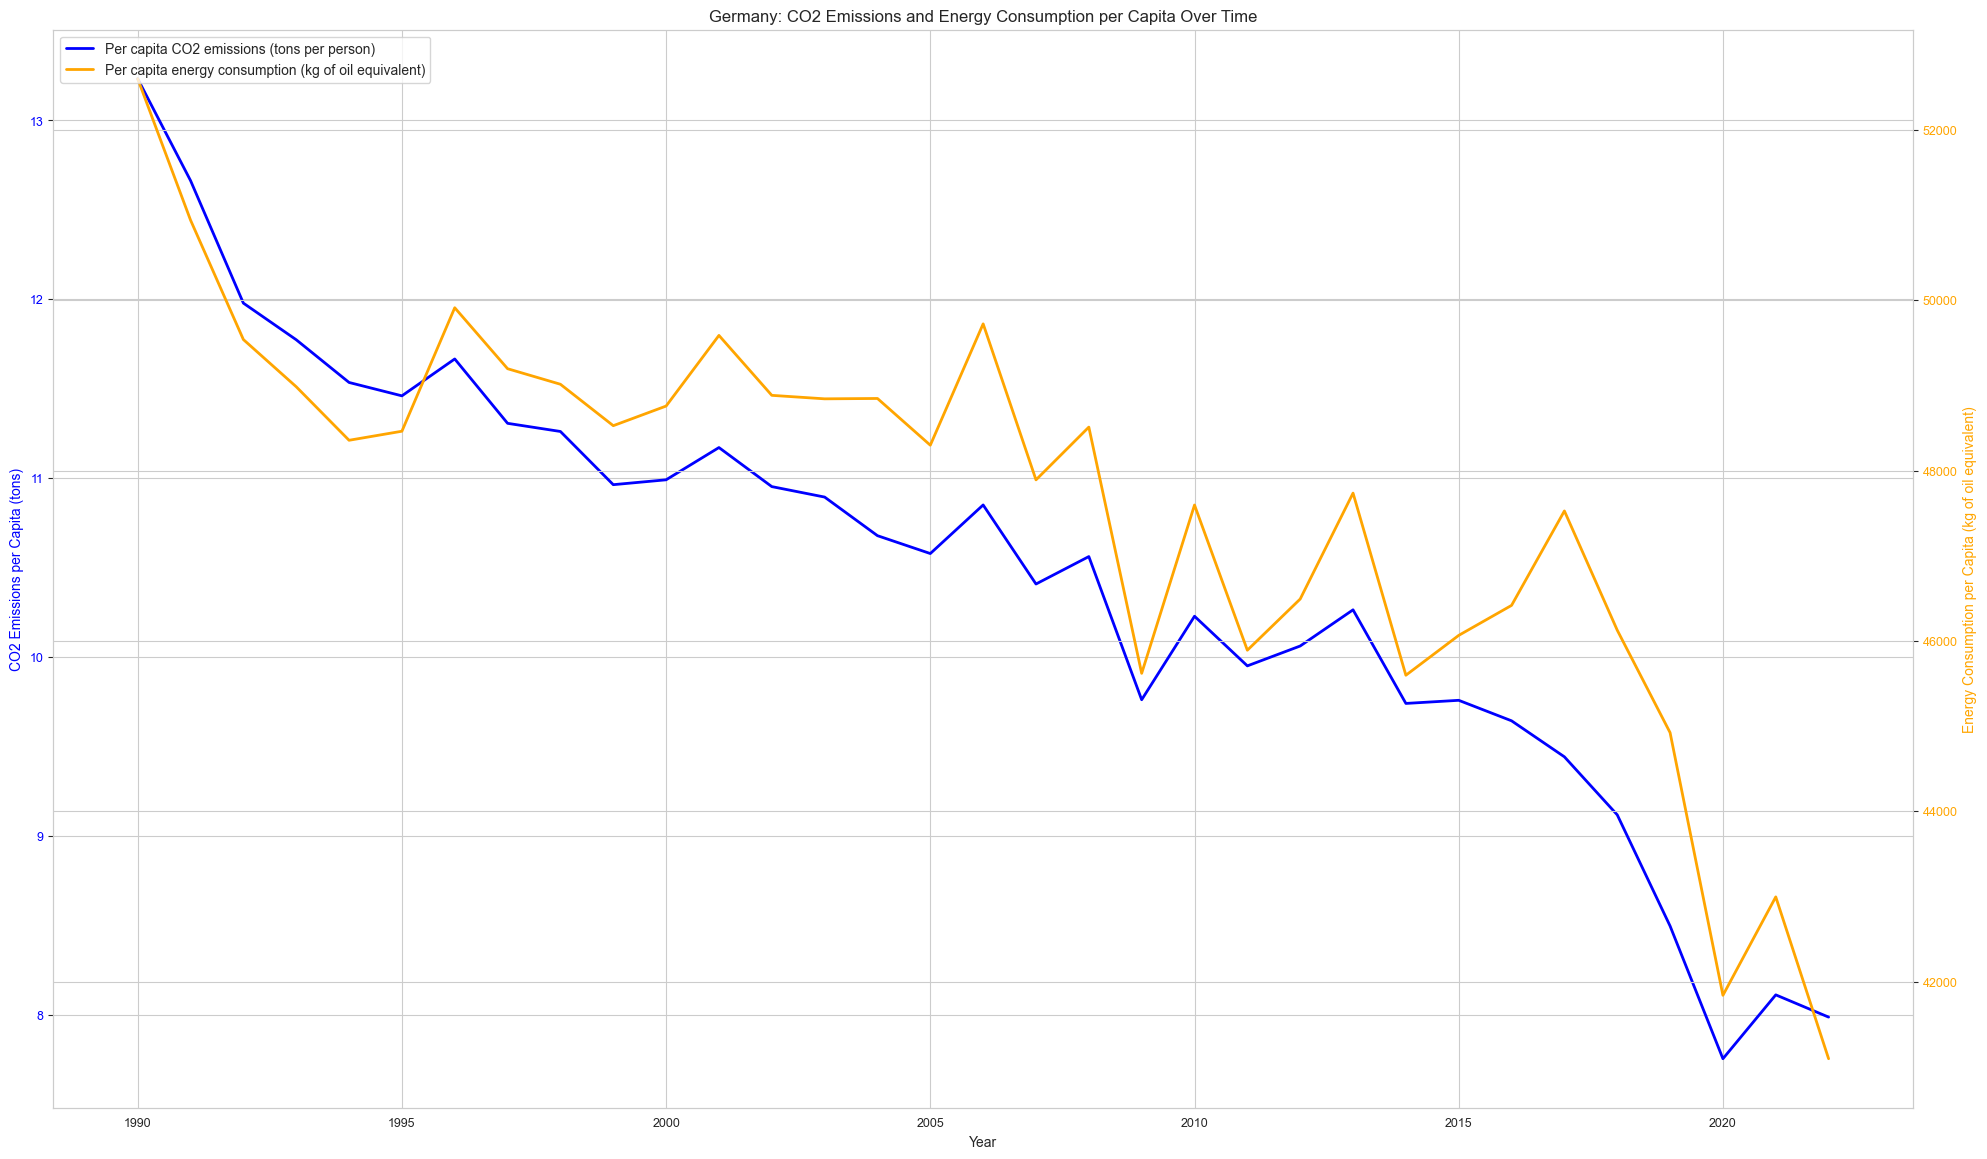

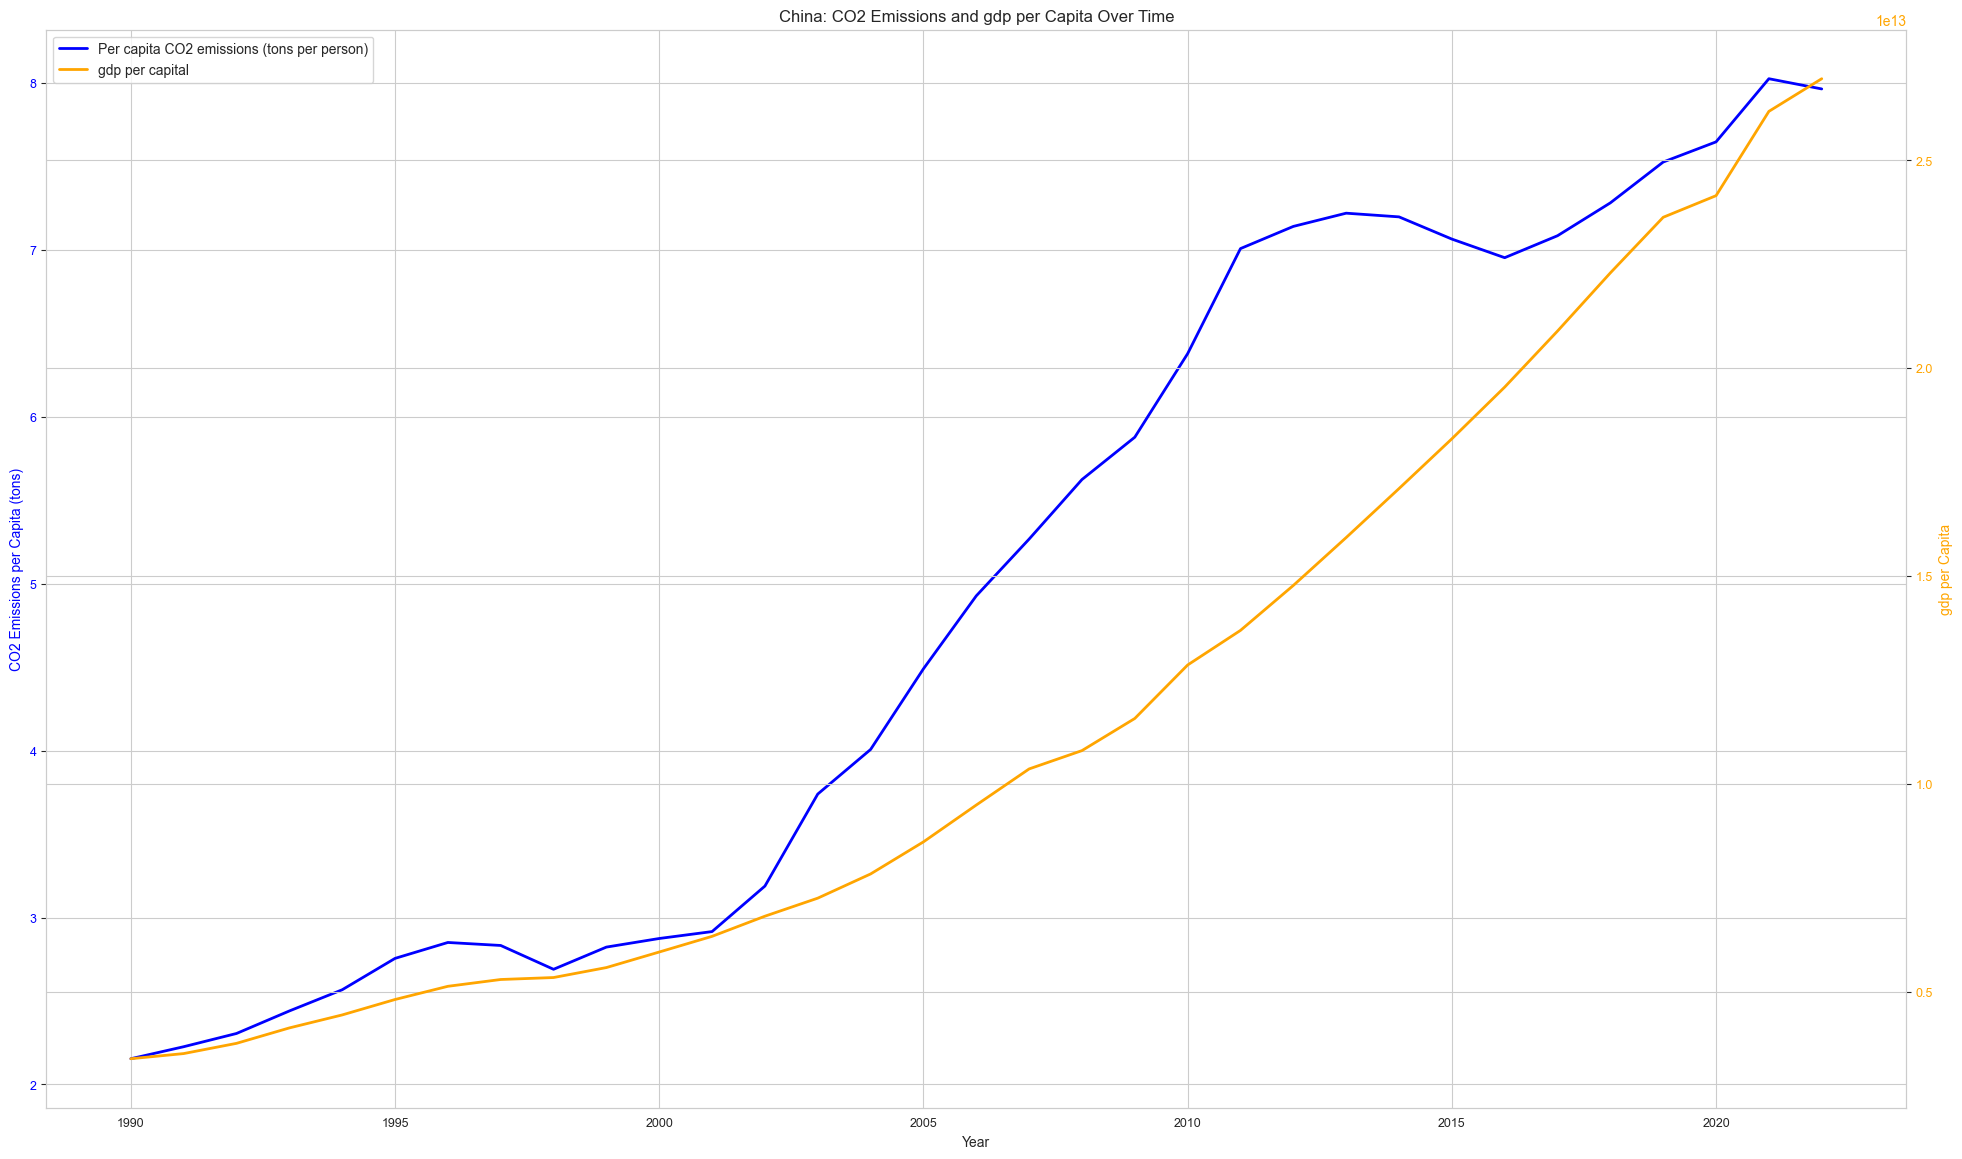

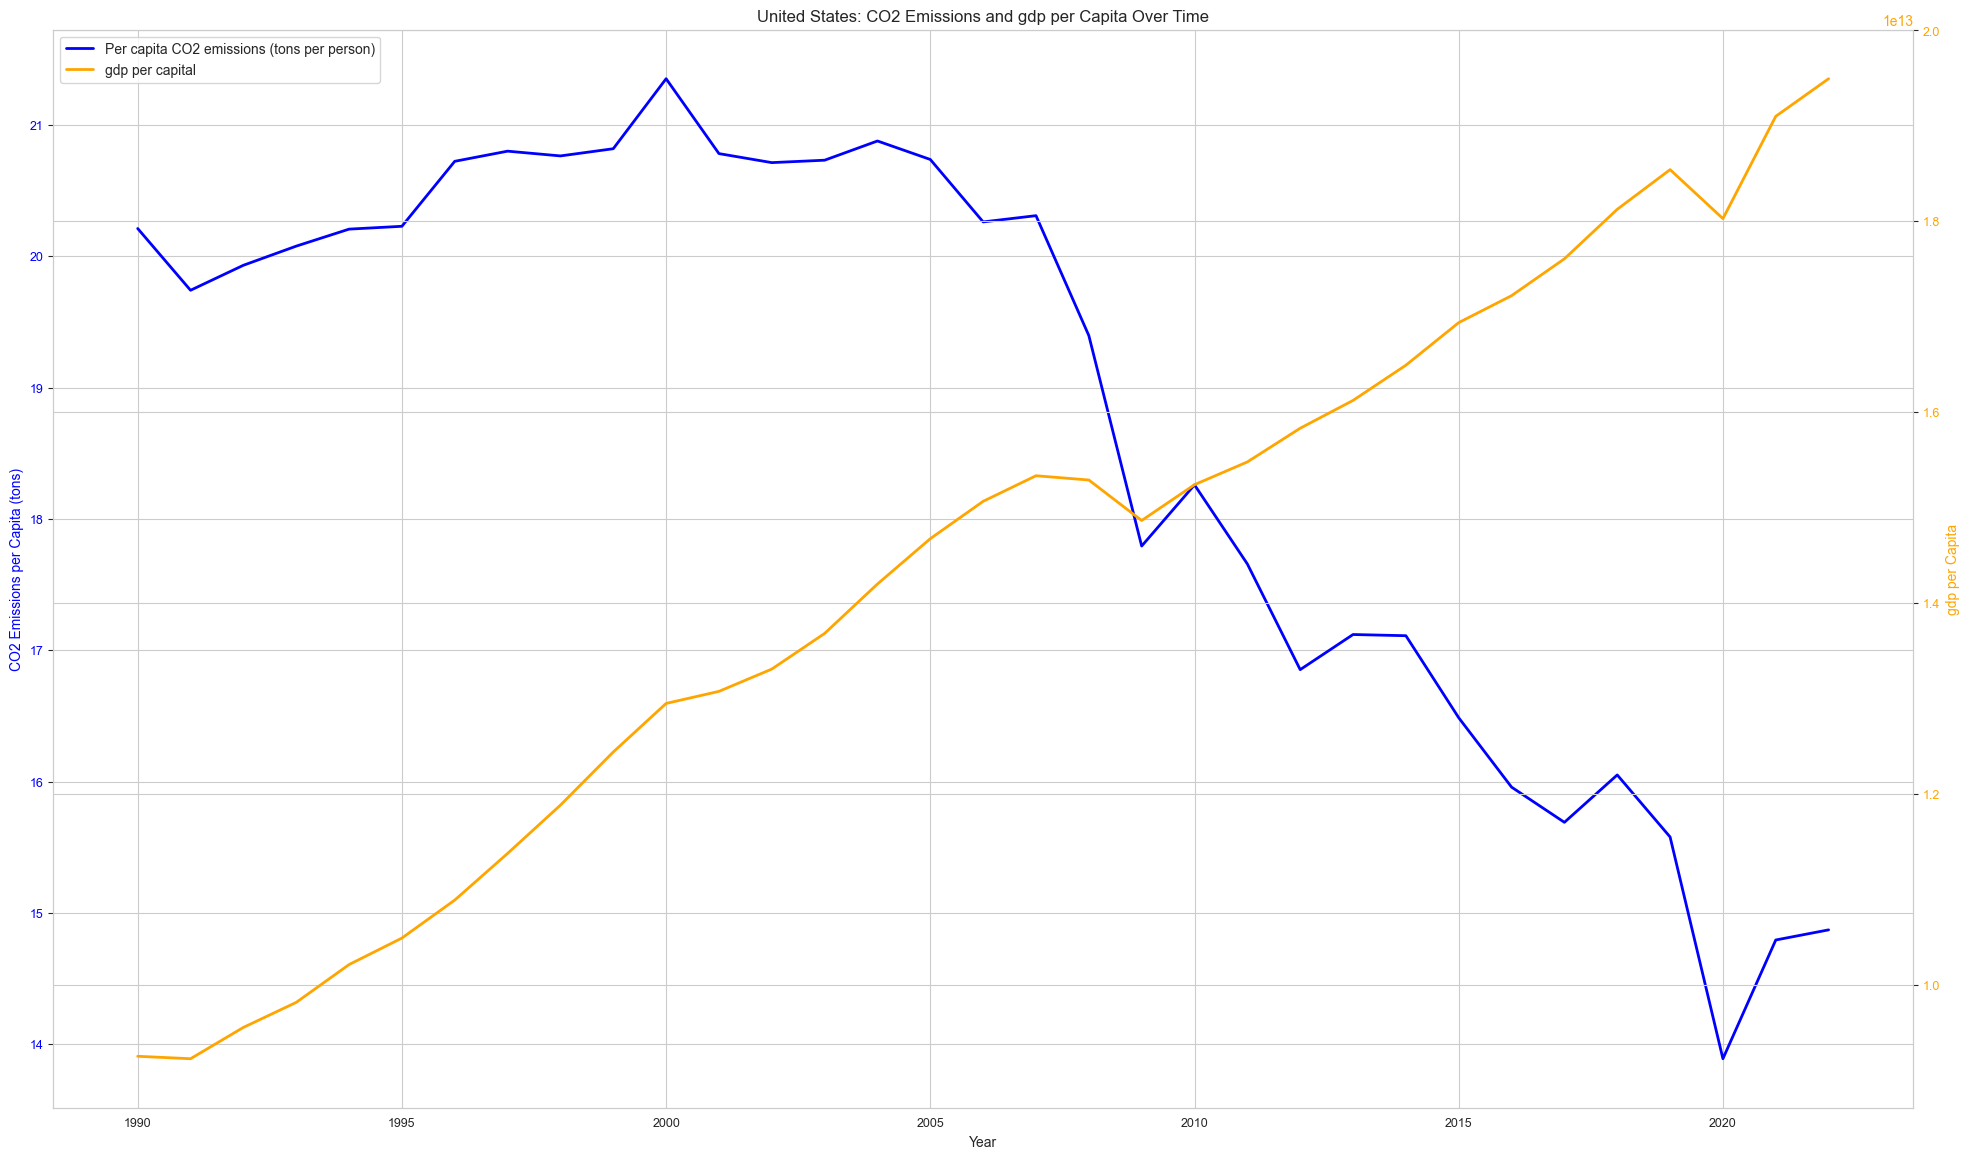

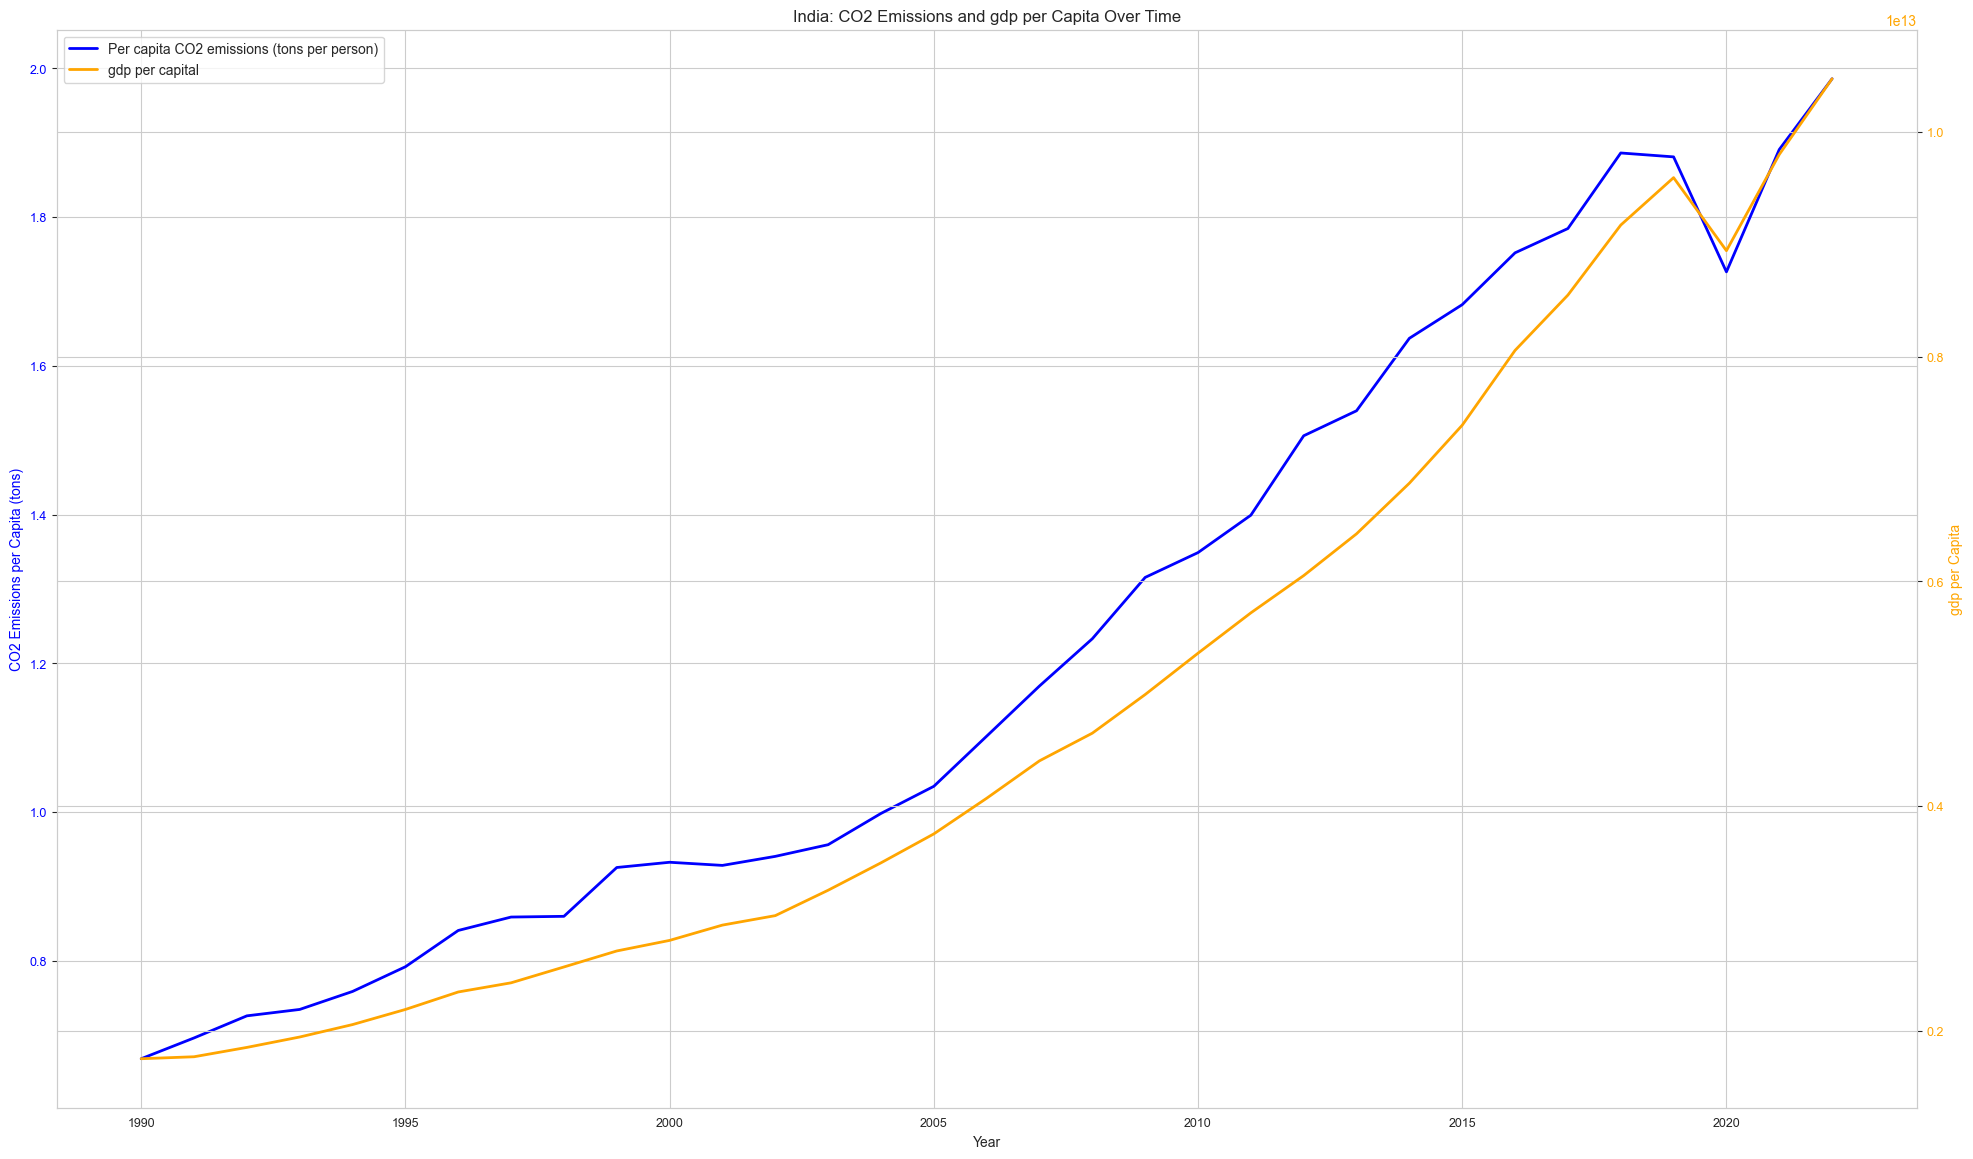

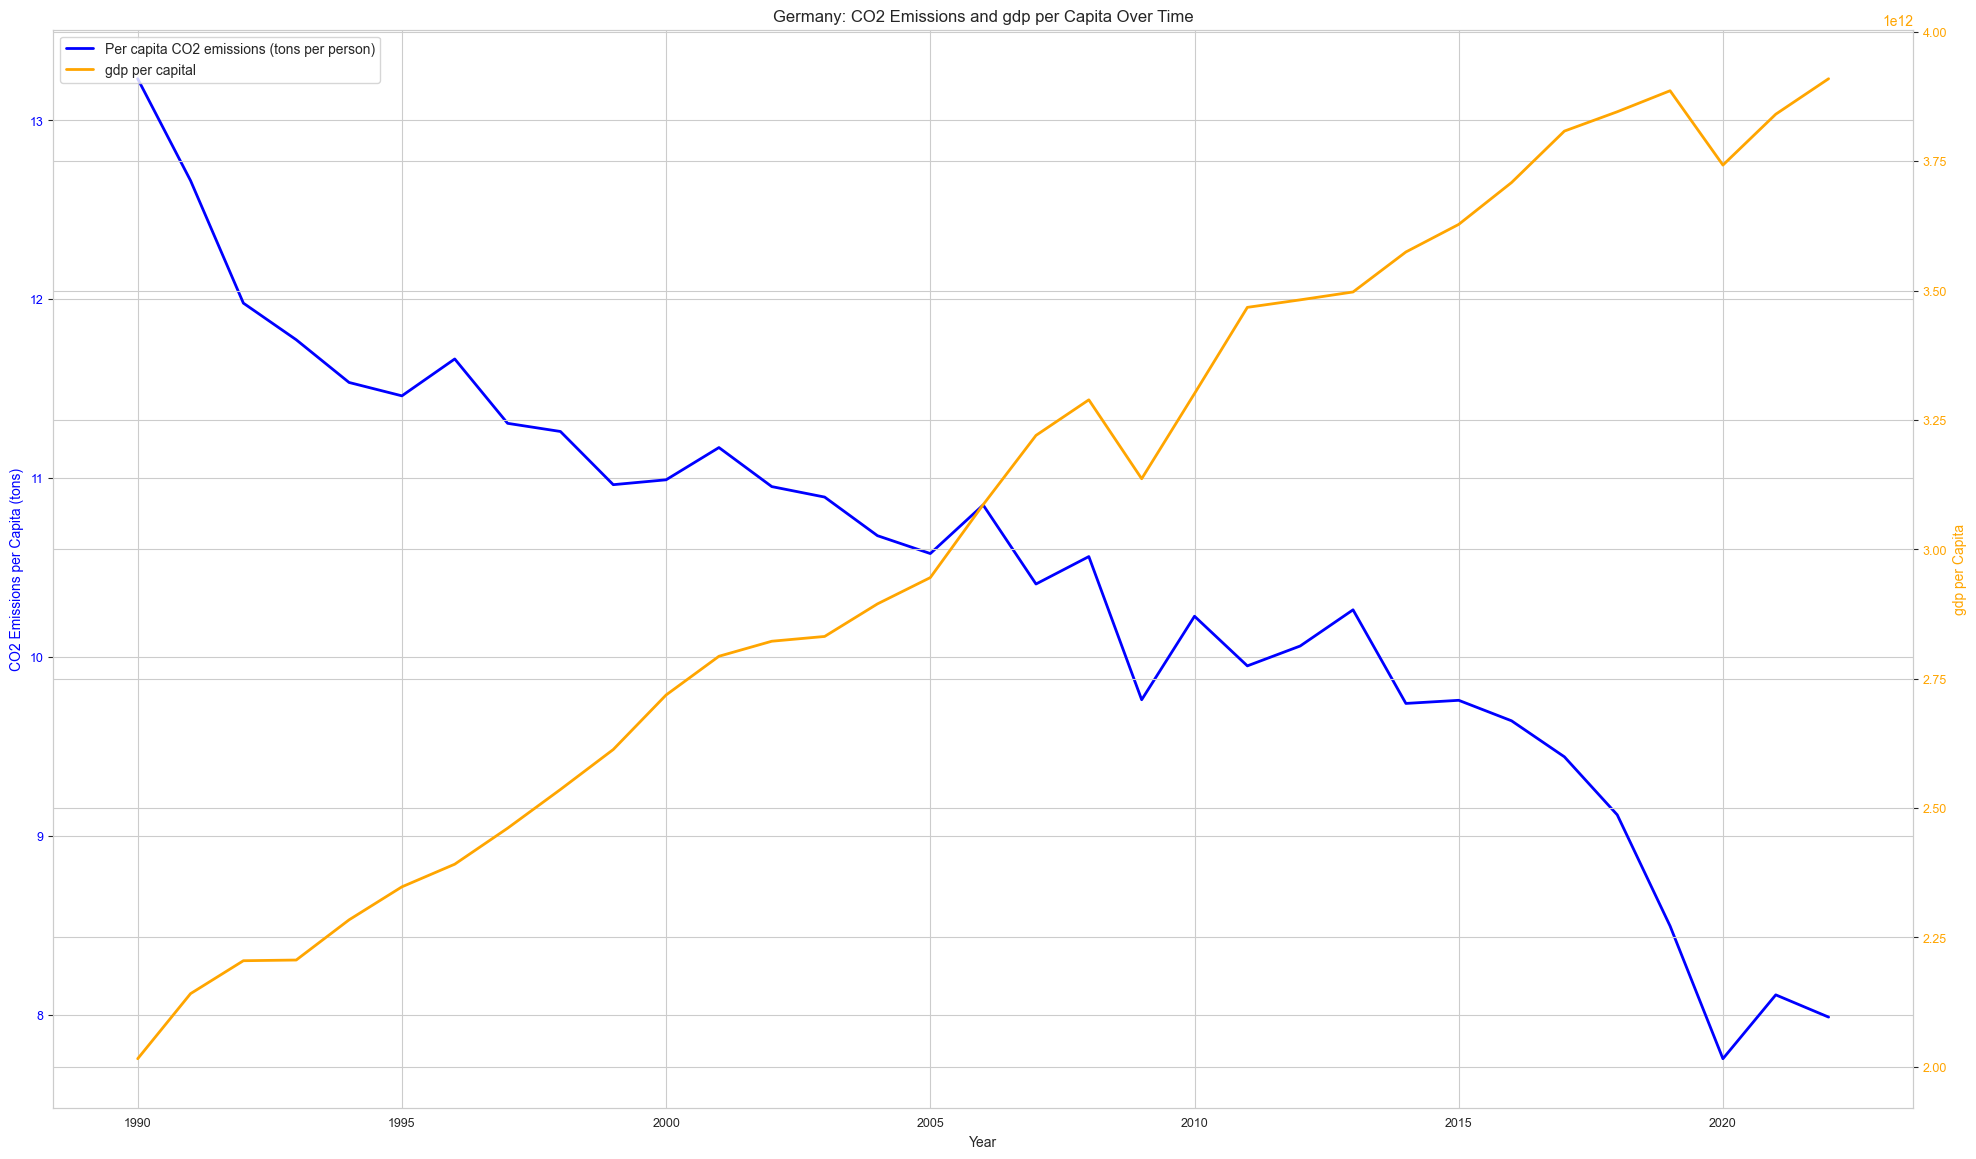

In [7]:
plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'China']['Year'],
         df[df['Countries'] == 'China']['CO2_Per_Capita'],
         label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'China']['Year'],
             df[df['Countries'] == 'China']['Energy_Per_Capita'],
             label='Per capita energy consumption (kg of oil equivalent)', color='orange', linewidth=2)
ax_twin.set_ylabel('Energy Consumption per Capita (kg of oil equivalent)', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('China: CO2 Emissions and Energy Consumption per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'United States']['Year'],
         df[df['Countries'] == 'United States']['CO2_Per_Capita'],
         label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'United States']['Year'],
                df[df['Countries'] == 'United States']['Energy_Per_Capita'],
                label='Per capita energy consumption (kg of oil equivalent)', color='orange', linewidth=2)
ax_twin.set_ylabel('Energy Consumption per Capita (kg of oil equivalent)', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('United States: CO2 Emissions and Energy Consumption per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'India']['Year'],
            df[df['Countries'] == 'India']['CO2_Per_Capita'],
            label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'India']['Year'],
                df[df['Countries'] == 'India']['Energy_Per_Capita'],
                label='Per capita energy consumption (kg of oil equivalent)', color='orange', linewidth=2)
ax_twin.set_ylabel('Energy Consumption per Capita (kg of oil equivalent)', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('India: CO2 Emissions and Energy Consumption per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'Germany']['Year'],
            df[df['Countries'] == 'Germany']['CO2_Per_Capita'],
            label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'Germany']['Year'],
                df[df['Countries'] == 'Germany']['Energy_Per_Capita'],
                label='Per capita energy consumption (kg of oil equivalent)', color='orange', linewidth=2)
ax_twin.set_ylabel('Energy Consumption per Capita (kg of oil equivalent)', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('Germany: CO2 Emissions and Energy Consumption per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'China']['Year'],
         df[df['Countries'] == 'China']['CO2_Per_Capita'],
         label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'China']['Year'],
             df[df['Countries'] == 'China']['gdp'],
             label='gdp per capital', color='orange', linewidth=2)
ax_twin.set_ylabel('gdp per Capita', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('China: CO2 Emissions and gdp per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'United States']['Year'],
         df[df['Countries'] == 'United States']['CO2_Per_Capita'],
         label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'United States']['Year'],
                df[df['Countries'] == 'United States']['gdp'],
                label='gdp per capital', color='orange', linewidth=2)
ax_twin.set_ylabel('gdp per Capita', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('United States: CO2 Emissions and gdp per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'India']['Year'],
            df[df['Countries'] == 'India']['CO2_Per_Capita'],
            label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'India']['Year'],
                df[df['Countries'] == 'India']['gdp'],
                label='gdp per capital', color='orange', linewidth=2)
ax_twin.set_ylabel('gdp per Capita', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('India: CO2 Emissions and gdp per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.figure(figsize=(24, 14))
plt.plot(df[df['Countries'] == 'Germany']['Year'],
            df[df['Countries'] == 'Germany']['CO2_Per_Capita'],
            label='Per capita CO2 emissions (tons per person)', color='blue', linewidth=2)
plt.ylabel('CO2 Emissions per Capita (tons)', color='blue', fontsize=10)
plt.xlabel('Year', fontsize=10)
plt.tick_params(axis='y', labelcolor='blue', labelsize=9)
plt.tick_params(axis='x', labelsize=9)
lines1, labels1 = plt.gca().get_legend_handles_labels()
ax_twin = plt.gca().twinx()
ax_twin.plot(df[df['Countries'] == 'Germany']['Year'],
                df[df['Countries'] == 'Germany']['gdp'],
                label='gdp per capital', color='orange', linewidth=2)
ax_twin.set_ylabel('gdp per Capita', color='orange', fontsize=10)
ax_twin.tick_params(axis='y', labelcolor='orange', labelsize=9)
plt.title('Germany: CO2 Emissions and gdp per Capita Over Time', fontsize=12)
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()

### Time-series plots of all countries

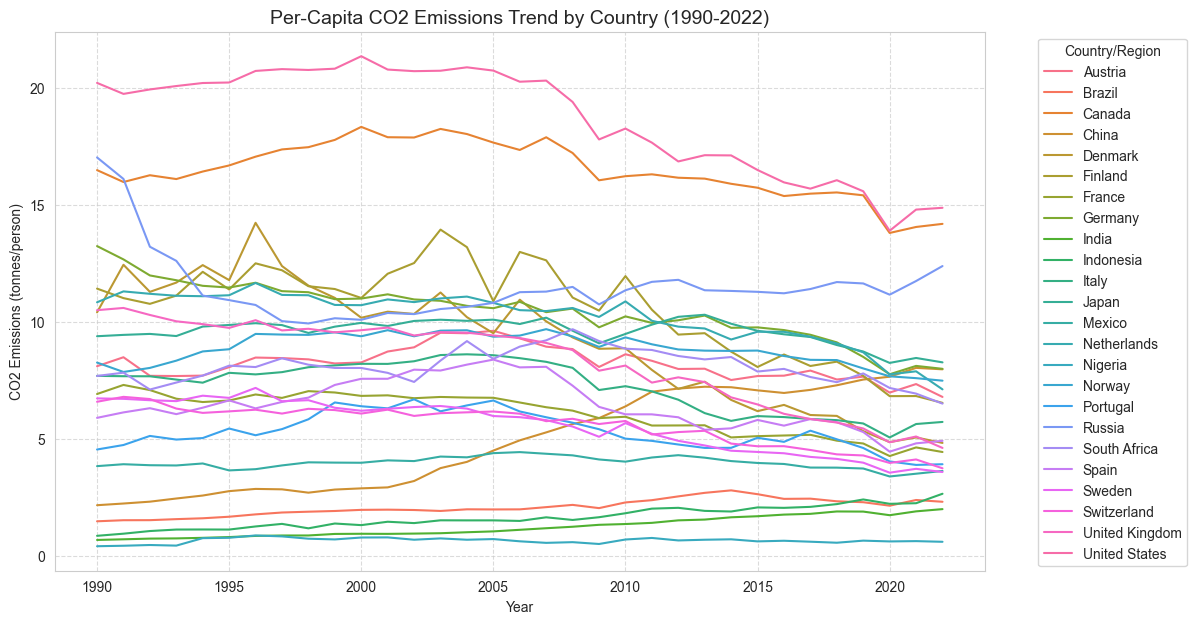

In [8]:
plt.figure(figsize=(12,7))
sns.lineplot(
    x='Year', 
    y='CO2_Per_Capita',
    data=df_data,
    hue='Countries'
)
plt.title('Per-Capita CO2 Emissions Trend by Country (1990-2022)',fontsize=14)
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (tonnes/person)')
plt.legend(title='Country/Region', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Heatmap

In [9]:
import plotly
import plotly.express as px
import plotly.io as pio

# 设置默认渲染器（在 Jupyter Notebook 中显示）
pio.renderers.default = "notebook"

country_to_iso = {
    'United States': 'USA',
    'Canada': 'CAN',
    'China': 'CHN',
    'Japan': 'JPN',
    'Germany': 'DEU',
    'United Kingdom': 'GBR',
    'France': 'FRA',
    'Italy': 'ITA',
    'Russia': 'RUS',
    'Spain': 'ESP',
    'Portugal': 'PRT',
    'Netherlands': 'NLD',
    'Denmark': 'DNK',
    'Finland': 'FIN',
    'Austria': 'AUT',
    'Norway': 'NOR',
    'Switzerland': 'CHE',
    'Sweden': 'SWE',
    'Indonesia': 'IDN',
    'South Africa': 'ZAF',
    'Nigeria': 'NGA',
    'Brazil': 'BRA',
    'Mexico': 'MEX'
}
group_data['ISO_Alpha3'] = group_data['Countries'].map(country_to_iso)

heat_map = px.choropleth(
    group_data,
    locations='ISO_Alpha3',
    locationmode='ISO-3',
    color='Average_CO2',
    hover_name='Countries',
    color_continuous_scale=px.colors.sequential.Reds,
    title='Average Per-Capita CO2 Emissions by Country (1990-2022)',
    labels={'Average_CO2': 'Avg. CO2 Emissions (tonnes/person)'}
)

# 更新布局，让地图更美观
heat_map.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    )
)
heat_map.show()

In [10]:

df_data['ISO_Alpha3'] = df_data['Countries'].map(country_to_iso)
df_data['ISO_Alpha3'] = df_data['Countries'].map(country_to_iso)
heat_map_animation = px.choropleth(
    df_data,
    locations='ISO_Alpha3',
    locationmode='ISO-3',
    color='CO2_Per_Capita',
    hover_name='Countries',
    animation_frame='Year',
    animation_group='Countries',
    color_continuous_scale=px.colors.sequential.Reds,
    title='Per-Capita CO2 Emissions by Country (1990-2022)',
    labels={'CO2_Per_Capita': 'CO2 Emissions (tonnes/person)'}
)
heat_map_animation.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
)
)
heat_map_animation.show()

In [11]:

df_data['ISO_Alpha3'] = df_data['Countries'].map(country_to_iso)
heat_map_animation = px.choropleth(
    df_data,
    locations='ISO_Alpha3',
    locationmode='ISO-3',
    color='Energy_Per_Capita',
    hover_name='Countries',
    animation_frame='Year',
    animation_group='Countries',
    color_continuous_scale=px.colors.sequential.Oranges,
    title='Per-Capita Energy Consumption by Country (1990-2022)',
    labels={'Energy_Per_Capita': 'Energy Consumption(kWh)'}
)
heat_map_animation.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
)
)
heat_map_animation.show()

# Data Processing

In [12]:
df_developed = pd.read_csv('./data/merge_data_developed.csv')
df_developing = pd.read_csv('./data/merge_data_developing.csv')
df_all = pd.read_csv('./data/merge_data_clean.csv')
df = pd.read_csv('./data/co2-emissions-per-capita.csv')
world = df[df['Entity'] == 'World']

# Feature Engineering

--- 相关性矩阵数值 ---
                population       gdp  CO2_Per_Capita
population        1.000000  0.981480        0.603348
gdp               0.981480  1.000000        0.601545
CO2_Per_Capita    0.603348  0.601545        1.000000


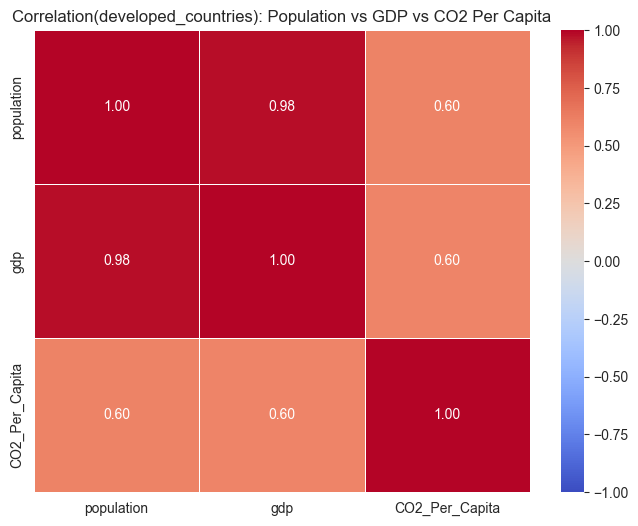

--- 相关性矩阵数值 ---
                population       gdp  CO2_Per_Capita
population        1.000000  0.746088       -0.191069
gdp               0.746088  1.000000        0.129988
CO2_Per_Capita   -0.191069  0.129988        1.000000


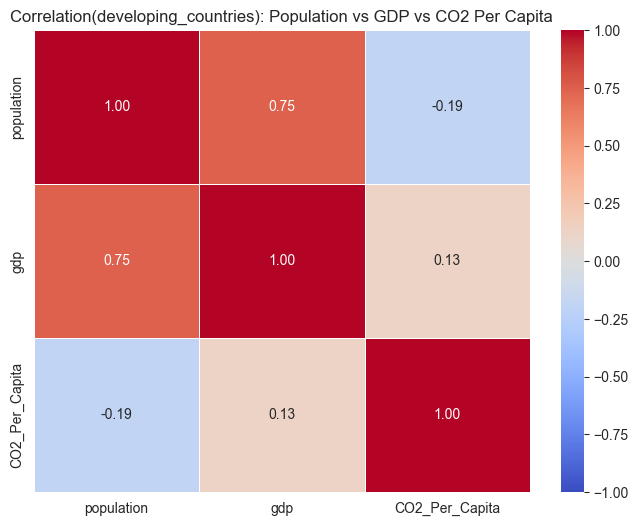

--- 相关性矩阵数值 ---
                population       gdp  CO2_Per_Capita
population        1.000000  0.616920       -0.271642
gdp               0.616920  1.000000        0.269681
CO2_Per_Capita   -0.271642  0.269681        1.000000


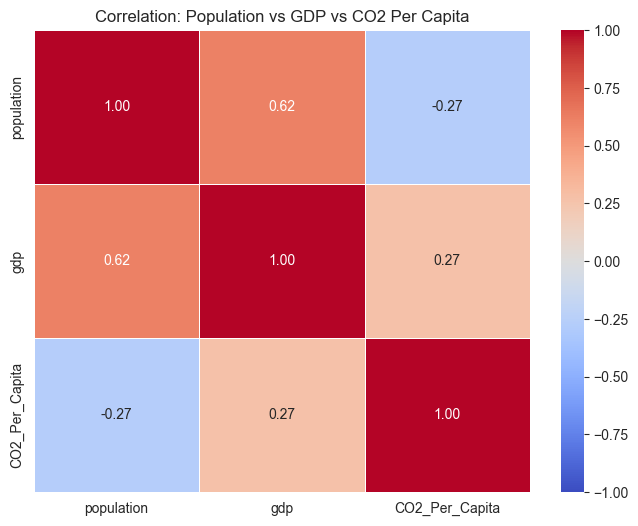

In [13]:
columns_of_interest = ['population', 'gdp', 'CO2_Per_Capita']
data_subset_1 = df_developed[columns_of_interest]
correlation_matrix_1 = data_subset_1.corr()
print("--- 相关性矩阵数值 ---")
print(correlation_matrix_1)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_1, 
            annot=True,     
            cmap='coolwarm', 
            fmt=".2f",       
            linewidths=0.5,  
            vmin=-1, vmax=1) 
plt.title('Correlation(developed_countries): Population vs GDP vs CO2 Per Capita')
plt.show()

data_subset_2 = df_developing[columns_of_interest]
correlation_matrix_2 = data_subset_2.corr()
print("--- 相关性矩阵数值 ---")
print(correlation_matrix_2)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_2,
            annot=True,     
            cmap='coolwarm', 
            fmt=".2f",       
            linewidths=0.5,  
            vmin=-1, vmax=1)
plt.title('Correlation(developing_countries): Population vs GDP vs CO2 Per Capita')
plt.show()

data_subset_1 = df_all[columns_of_interest]
correlation_matrix_1 = data_subset_1.corr()
print("--- 相关性矩阵数值 ---")
print(correlation_matrix_1)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_1, 
            annot=True,     
            cmap='coolwarm', 
            fmt=".2f",       
            linewidths=0.5,  
            vmin=-1, vmax=1) 
plt.title('Correlation: Population vs GDP vs CO2 Per Capita')
plt.show()




# Model_1: Developed_countries

## Data Gathering and Splitting

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df_developed[['gdp', 'Year']]
y = df_developed['CO2_Per_Capita']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

##  Model Training and predicting

In [15]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)
future_years = np.arange(2023, 2033)
mean_gdp_by_year = df_developed.groupby('Year')['gdp'].mean()
gdp_trend_model = np.poly1d(np.polyfit(mean_gdp_by_year.index, mean_gdp_by_year.values, 1))
future_gdp_est = gdp_trend_model(future_years)
future_data = pd.DataFrame({
    'gdp': future_gdp_est,
    'Year': future_years
})
future_X_scaled = scaler.transform(future_data)
future_X_poly = poly.transform(future_X_scaled)
future_pred = model.predict(future_X_poly)

print("\n--- 2023-2032 预测结果 (人均排放量) ---")
for year, pred in zip(future_years, future_pred):
    print(f"{year}年: {pred:.4f}")




--- 2023-2032 预测结果 (人均排放量) ---
2023年: 6.0636
2024年: 5.7608
2025年: 5.4463
2026年: 5.1202
2027年: 4.7823
2028年: 4.4328
2029年: 4.0716
2030年: 3.6988
2031年: 3.3142
2032年: 2.9180


## Model Inference and Evaluation

In [16]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
score = model.score(X_test_poly, y_test)
print(f"--- 模型评估报告 (Degree = 2) ---")
print(f"1. R2 Score (拟合优度): {r2:.4f}")
print(f"2. MSE (均方误差): {mse:.4f}")
print(f"3. RMSE (均方根误差): {rmse:.4f}")
print(f"4. MAE (平均绝对误差): {mae:.4f}")
print(f"5. Model Score: {score:.4f}")

--- 模型评估报告 (Degree = 2) ---
1. R2 Score (拟合优度): 0.5218
2. MSE (均方误差): 8.3997
3. RMSE (均方根误差): 2.8982
4. MAE (平均绝对误差): 2.1566
5. Model Score: 0.5218


## Visualization

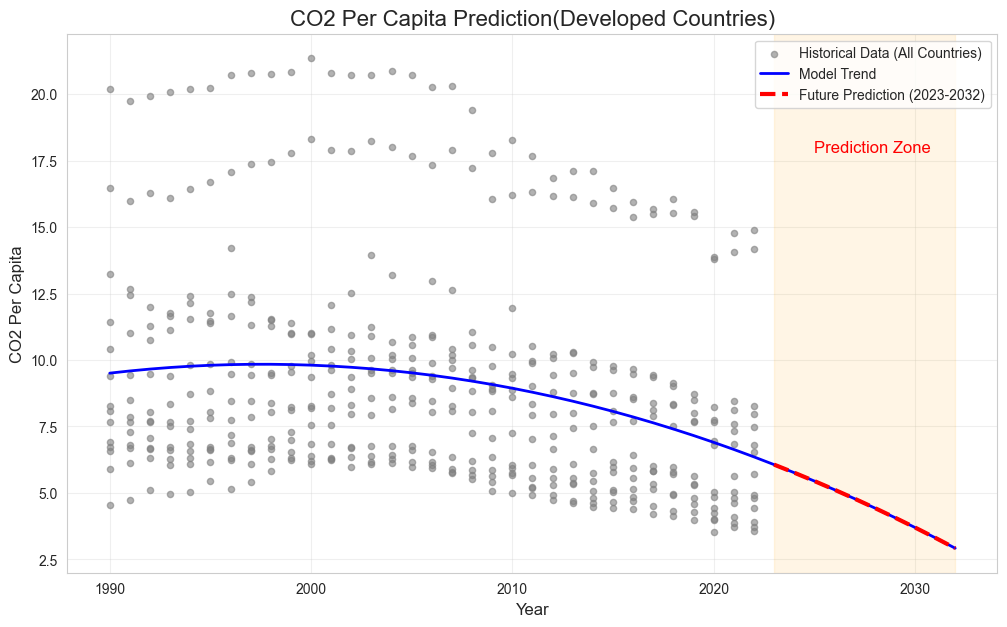

In [17]:
plt.figure(figsize=(12, 7))
plt.scatter(df_developed['Year'], df_developed['CO2_Per_Capita'], alpha=0.6, c='gray', label='Historical Data (All Countries)', s=20)
plot_years = np.arange(df_developed['Year'].min(), 2033)
plot_gdp = gdp_trend_model(plot_years)
plot_X = pd.DataFrame({'gdp': plot_gdp, 'Year': plot_years})
plot_X_scaled = scaler.transform(plot_X)
plot_X_poly = poly.transform(plot_X_scaled)
plot_y_pred = model.predict(plot_X_poly)
plt.plot(plot_years, plot_y_pred, color='blue', linewidth=2, label='Model Trend')
plt.plot(future_years, future_pred, color='red', linewidth=3, linestyle='--', label='Future Prediction (2023-2032)')
plt.title(f'CO2 Per Capita Prediction(Developed Countries)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Per Capita', fontsize=12)
plt.legend(loc = 'upper right')
plt.grid(True, alpha=0.3)
plt.axvspan(2023, 2032, color='orange', alpha=0.1)
plt.text(2025, plt.ylim()[1]*0.8, 'Prediction Zone', color='red', fontsize=12)
plt.show()

# Model_2: Developing_countries

## Failed to properly predicet：Since developing countries differ from each other significantly.

--- 模型评估报告 (Degree 2) ---
1. R2 Score (拟合优度): -0.0556
2. MSE (均方误差): 12.9282
3. RMSE (均方根误差): 3.5956
4. MAE (平均绝对误差): 3.0967
5. Model Score: -0.0556

--- 2023-2032 发展中国家平均趋势预测 ---
2023年: 3.7304
2024年: 3.6903
2025年: 3.6482
2026年: 3.6040
2027年: 3.5576
2028年: 3.5092
2029年: 3.4586
2030年: 3.4060
2031年: 3.3512
2032年: 3.2944


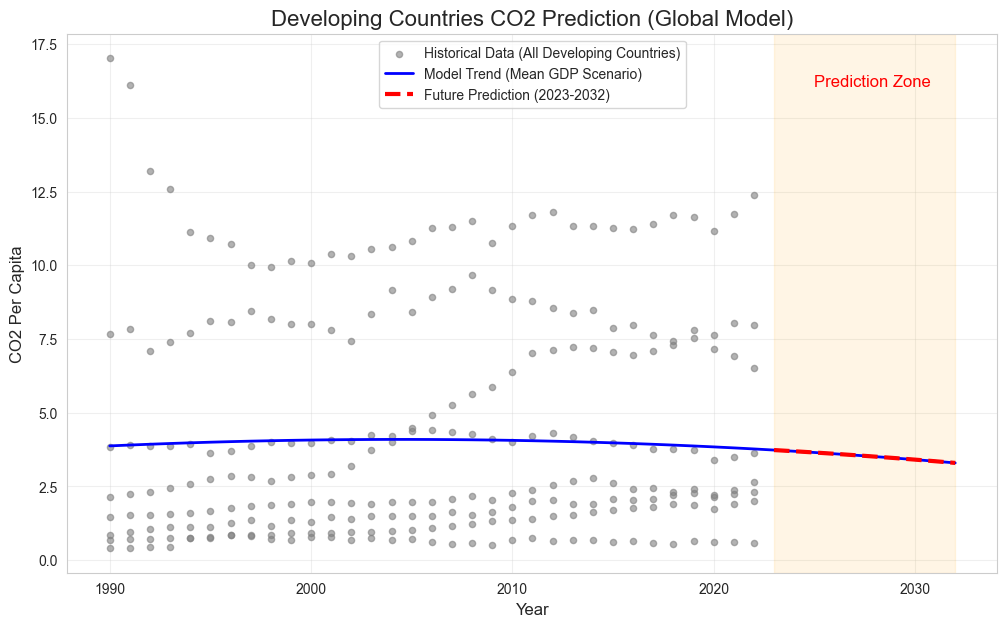

In [18]:
X = df_developing[['gdp', 'Year']]
y = df_developing['CO2_Per_Capita']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
poly_degree = 2
poly = PolynomialFeatures(degree=poly_degree)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
score = model.score(X_test_poly, y_test)
print(f"--- 模型评估报告 (Degree {poly_degree}) ---")
print(f"1. R2 Score (拟合优度): {r2:.4f}")
print(f"2. MSE (均方误差): {mse:.4f}")
print(f"3. RMSE (均方根误差): {rmse:.4f}")
print(f"4. MAE (平均绝对误差): {mae:.4f}")
print(f"5. Model Score: {score:.4f}")

future_years = np.arange(2023, 2033)
mean_gdp_by_year = df_developing.groupby('Year')['gdp'].mean()
gdp_trend_model = np.poly1d(np.polyfit(mean_gdp_by_year.index, mean_gdp_by_year.values, 1))
future_gdp_est = gdp_trend_model(future_years)
future_data = pd.DataFrame({
    'gdp': future_gdp_est,
    'Year': future_years
})
future_X_scaled = scaler.transform(future_data)
future_X_poly = poly.transform(future_X_scaled)
future_pred = model.predict(future_X_poly)
print("\n--- 2023-2032 发展中国家平均趋势预测 ---")
for year, pred in zip(future_years, future_pred):
    print(f"{year}年: {pred:.4f}")

plt.figure(figsize=(12, 7))
plt.scatter(df_developing['Year'], df_developing['CO2_Per_Capita'], alpha=0.6, c='gray', label='Historical Data (All Developing Countries)', s=20)
plot_years = np.arange(df_developing['Year'].min(), 2033)
plot_gdp = gdp_trend_model(plot_years)
plot_X = pd.DataFrame({'gdp': plot_gdp, 'Year': plot_years})
plot_X_scaled = scaler.transform(plot_X)
plot_X_poly = poly.transform(plot_X_scaled)
plot_y_pred = model.predict(plot_X_poly)
plt.plot(plot_years, plot_y_pred, color='blue', linewidth=2, label='Model Trend (Mean GDP Scenario)')
plt.plot(future_years, future_pred, color='red', linewidth=3, linestyle='--', label='Future Prediction (2023-2032)')
plt.title(f'Developing Countries CO2 Prediction (Global Model)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Per Capita', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvspan(2023, 2032, color='orange', alpha=0.1)
plt.text(2025, plt.ylim()[1]*0.9, 'Prediction Zone', color='red', fontsize=12)
plt.show()

# Model_3: World
## Using the average data of the world

## Data gathering and Splitting

In [19]:
world = world[(world['Year'] >= 1900) & (world['Year'] <= 2022)]
X = world[['Year']].values
y = world['Annual CO₂ emissions (per capita)'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## Model Training and predicting


In [20]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)
future_years = np.arange(2023, 2033).reshape(-1, 1)
future_years_poly = poly.transform(future_years)
future_pred = model.predict(future_years_poly)
print("\n--- 2023-2032 世界平均人均排放量预测 ---")
for year, pred in zip(future_years.flatten(), future_pred):
    print(f"{year}年: {pred:.4f}")


--- 2023-2032 世界平均人均排放量预测 ---
2023年: 5.0425
2024年: 5.0707
2025年: 5.0988
2026年: 5.1268
2027年: 5.1548
2028年: 5.1827
2029年: 5.2106
2030年: 5.2383
2031年: 5.2660
2032年: 5.2936


## Model Inference and Evaluation


In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
score = model.score(X_test_poly, y_test)
print(f"--- 模型评估报告 (World Model, Degree = 2) ---")
print(f"1. R2 Score (拟合优度): {r2:.4f}")
print(f"2. MSE (均方误差): {mse:.4f}")
print(f"3. RMSE (均方根误差): {rmse:.4f}")
print(f"4. MAE (平均绝对误差): {mae:.4f}")
print(f"5. Model Score: {score:.4f}")

--- 模型评估报告 (World Model, Degree = 2) ---
1. R2 Score (拟合优度): 0.9034
2. MSE (均方误差): 0.1290
3. RMSE (均方根误差): 0.3592
4. MAE (平均绝对误差): 0.2910
5. Model Score: 0.9034


## Visualization


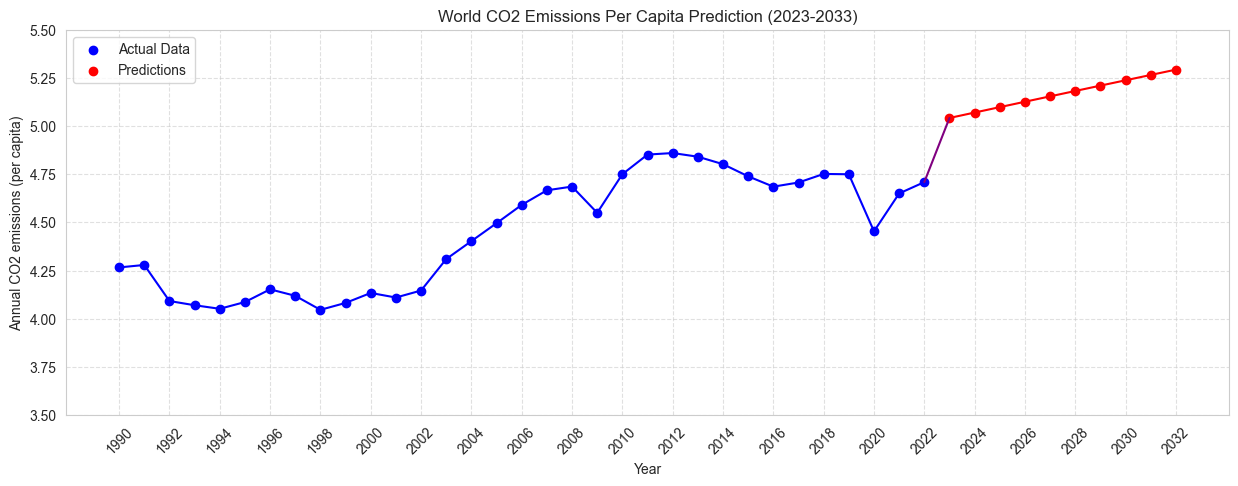

In [22]:
actual_data = world[(world['Year'] >= 1990)& (world['Year'] <= 2022)]
plt.figure(figsize=(15, 5))
plt.scatter(
    actual_data['Year'], 
    actual_data['Annual CO₂ emissions (per capita)'], 
    color='blue', label='Actual Data'
    )
plt.plot(
    actual_data['Year'], 
    actual_data['Annual CO₂ emissions (per capita)'], 
    color='blue'
    )
plt.scatter(
    np.arange(2023, 2033), 
    future_pred, 
    color='red', 
    label='Predictions'
    )
plt.plot(
    np.arange(2023, 2033), 
    future_pred, 
    color='red'
    )
plt.plot(
    [2022,2023], 
    [actual_data[actual_data['Year']==2022]['Annual CO₂ emissions (per capita)'].values[0], future_pred[0]], 
    color='purple'
    )
plt.ylim(2.5,5.5)
plt.xticks(np.arange(1990, 2033, 2), rotation=45)
plt.title('World CO2 Emissions Per Capita Prediction (2023-2033)')
plt.xlabel('Year')
plt.ylabel('Annual CO2 emissions (per capita)')
plt.legend(loc='upper left')
plt.ylim(3.5, 5.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Clustering with K-means

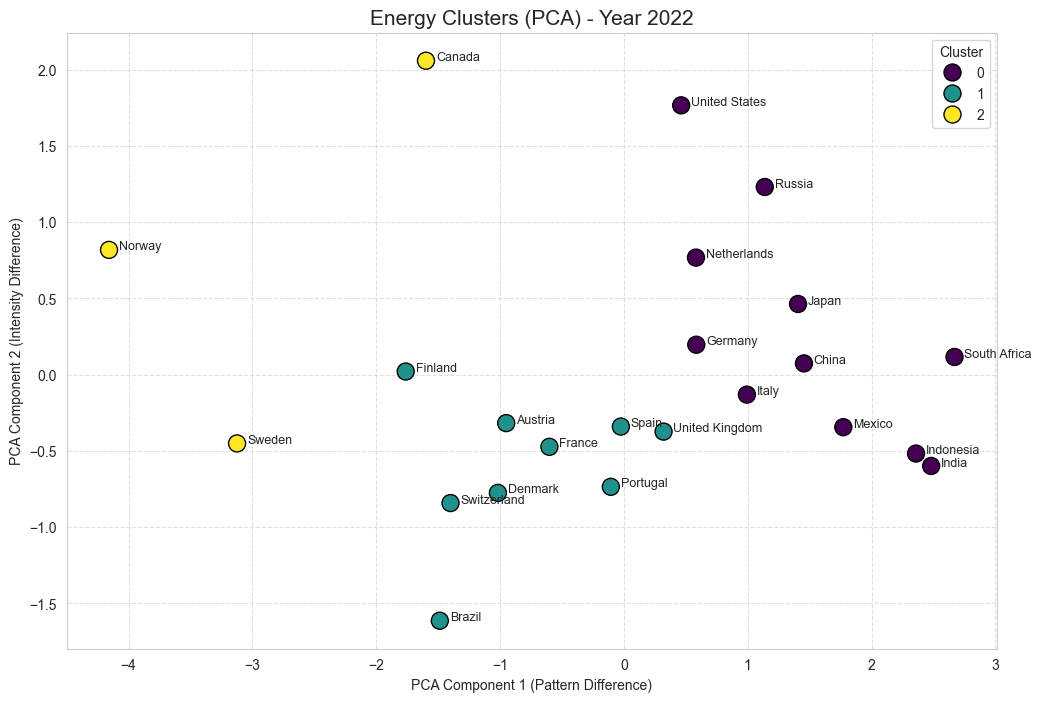

--- Interpretation ---

Component 1:
正方向表示化石能源占比;
负方向表示可再生能源占比

Component 2:
数值越高表示排放强度越高

Cluster 0 (高碳高依赖组)
Cluster 1 (结构平衡组)
Cluster 2 (高耗清洁组)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from math import pi

df_cluster = pd.read_csv('./data/clustering_data.csv', index_col = 'country')
data_scaled = scaler.fit_transform(df_cluster)
k = 3 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)
df_cluster['Cluster'] = clusters

pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x = pca_components[:, 0], y = pca_components[:, 1], 
                hue = df_cluster['Cluster'], palette = 'viridis', s = 150, edgecolor = 'k')
for i, txt in enumerate(df_cluster.index):
    plt.text(pca_components[i, 0]+0.08, pca_components[i, 1], txt, fontsize=9)
plt.title(f'Energy Clusters (PCA) - Year 2022', fontsize=15)
plt.xlabel('PCA Component 1 (Pattern Difference)')
plt.ylabel('PCA Component 2 (Intensity Difference)')
plt.legend(title = 'Cluster')
plt.grid(True, linestyle = '--', alpha=0.6)
plt.show()
print('--- Interpretation ---\n')
print('Component 1:\n正方向表示化石能源占比;\n负方向表示可再生能源占比\n')
print('Component 2:\n数值越高表示排放强度越高\n')
print('Cluster 0 (高碳高依赖组)')
print('Cluster 1 (结构平衡组)')
print('Cluster 2 (高耗清洁组)')
